In [9]:
import os
import math
import warnings
from datetime import datetime, timedelta
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import DataConversionWarning
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from stable_baselines3 import PPO

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [11]:
def read_and_merge_csvs(folder_path):
    # Find all CSV files in the folder
    all_csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    # Read all CSVs into a list of DataFrames
    df_list = [pd.read_csv(file) for file in all_csv_files]

    # Merge all DataFrames (concatenating them)
    merged_df = pd.concat(df_list, ignore_index=True)

    return merged_df

In [12]:
warnings.filterwarnings("ignore", category=UserWarning, message=".*precision lowered by casting to float32.*")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*torch.load.*weights_only=False.*")

In [13]:
mesa_df = read_and_merge_csvs("2025-03-19-mesa-de-sol-microgrid-data")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv")
wind_df = pd.read_csv("2025-03-30-dwse-wind-data/Wind Time Series Dataset(10min).csv")
price_df = pd.read_csv("2025-03-24-ieso-hourly-ontario-energy-price/PUB_PriceHOEPPredispOR_2024.csv", skiprows=0)
critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/CenterHall.csv")
non_critical_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/EastCampus.csv")
essential_load_df = pd.read_csv("2025-03-29-uscd-microgrid-data/BuildingLoad/GalbraithHall.csv")
temperature_df = pd.read_csv("2025-04-09-ontario-hourly-temperature/hourly-temperature.csv", usecols=['LOCAL_DATE', 'TEMP'])

In [15]:
# Preprocess and align all datasets to 5-minute intervals (ignores year)
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Create a primary matching key for mesa data
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])

    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])

    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
    wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
    
    critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
    critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    critical_load_data = critical_load_data.reset_index()
    critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
    critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
    critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
    non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    non_critical_load_data = non_critical_load_data.reset_index()
    non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
    non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
    non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
    essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    essential_load_data = essential_load_data.reset_index()
    essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
    essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
    essential_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
    temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
    temperature_data = temperature_data.reset_index()
    temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
    temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
    temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        non_critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        essential_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        temperature_data.drop(columns=['LOCAL_DATE']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    # Define columns that can logically have negative values
    can_be_negative = [
       'Battery_Active_Power', 
       'Battery_Active_Power_Set_Response',
       'Island_mode_MCCB_Active_Power',
       'Temperature',
    ]
    
    # Set bounds for extreme values
    lower_bound = -9999
    upper_bound = 9999
    
    # Process each column
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           if column in can_be_negative:
               # For columns that can be negative, only remove extreme values
               mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
           else:
               # For columns that shouldn't be negative, remove negative values and extremes
               mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
           
           merged_data.loc[mask, column] = np.nan
    
    # Use interpolation to fill missing values (maintains time series patterns)
    merged_data = merged_data.interpolate(method='linear')
    
    # Use forward fill and backward fill for any remaining NaN values at the edges
    merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
    
    # Use median for any columns that still have NaN values
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           merged_data[column] = merged_data[column].fillna(merged_data[column].median())


    # Scaling data
    load_scaling_factor = 0.95
    merged_data['Critical_Power_Load'] = merged_data['Critical_Power_Load'] * load_scaling_factor
    merged_data['Essential_Power_Load'] = merged_data['Essential_Power_Load'] * load_scaling_factor
    merged_data['Non_Critical_Power_Load'] = merged_data['Non_Critical_Power_Load'] * load_scaling_factor
    

    # Removing major outliers
    columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
    percentile = 90
    for col in columns:
        threshold = merged_data[col].quantile(percentile / 100)
        mean_val = merged_data[col].mean()
        merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
    
    # Removing columns
    excluded_cols = [
        'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
        'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
        'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
    ]
    
    merged_data.drop(columns=excluded_cols, inplace=True)
    
    return merged_data

In [16]:
merged_df = preprocess_data(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

/var/folders/qd/1pjv967d1ylfl4mzr8flbvb00000gn/T/ipykernel_99750/67258842.py:131: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')


In [17]:
merged_df.to_csv("merged.csv", index=False)

In [11]:
mesa_df.columns

Index(['Timestamp', 'Battery_Active_Power',
       'Battery_Active_Power_Set_Response', 'PVPCS_Active_Power',
       'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency',
       'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'],
      dtype='object')

In [12]:
mesa_df.head()

,Timestamp,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,MG-LV-MSB_AC_Voltage,Receiving_Point_AC_Voltage,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,Inlet_Temperature_of_Chilled_Water,Outlet_Temperature
0,2023/05/01 00:00:01,0.0,0.0,0.0,0.0,-0.2,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,480.0,59.990002,59.990002,15.0,14.8
1,2023/05/01 00:00:11,0.0,0.0,0.0,0.0,-0.5,200.0,40.0,38.0,40.0,-13.0,480.0,480.0,480.0,59.970001,59.970001,14.9,14.8
2,2023/05/01 00:00:21,-0.2,0.0,0.0,0.0,-1.2,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,479.0,59.980000,59.980000,15.0,14.8
3,2023/05/01 00:00:31,-0.1,0.0,0.0,0.0,-0.7,200.0,40.0,38.0,40.0,-14.0,479.0,480.0,480.0,59.970001,59.970001,14.9,14.8
4,2023/05/01 00:00:41,-0.1,0.0,0.0,0.0,-0.7,200.0,40.0,38.0,40.0,-13.0,479.0,480.0,479.0,59.970001,59.970001,15.0,14.8


In [13]:
price_df.columns

Index(['Date', 'Hour', 'HOEP', 'Hour 1 Predispatch', 'Hour 2 Predispatch',
       'Hour 3 Predispatch', 'OR 10 Min Sync', 'OR 10 Min non-sync',
       'OR 30 Min'],
      dtype='object')

In [14]:
price_df.head()

,Date,Hour,HOEP,Hour 1 Predispatch,Hour 2 Predispatch,Hour 3 Predispatch,OR 10 Min Sync,OR 10 Min non-sync,OR 30 Min
0,2024-01-01,1,46.42,34.68,33.80,27.83,1.26,0.17,0.17
1,2024-01-01,2,35.85,33.73,32.13,33.80,0.98,0.15,0.15
2,2024-01-01,3,27.73,33.73,27.22,29.86,0.98,0.15,0.15
3,2024-01-01,4,19.34,27.35,27.26,27.34,0.15,0.11,0.10
4,2024-01-01,5,20.23,27.20,27.26,27.27,0.10,0.10,0.10


In [15]:
wind_df.columns

Index(['Time', 'WindSpeed', 'Power'], dtype='object')

In [16]:
wind_df.head()

,Time,WindSpeed,Power
0,2014-10-07 01:20:00,8.22,40.526173
1,2014-10-07 01:30:00,8.09,38.552540
2,2014-10-07 01:50:00,7.21,21.313683
3,2014-10-07 02:00:00,6.75,18.031418
4,2014-10-07 02:10:00,6.52,16.593281


In [17]:
critical_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,69.119,41.171
1,2/29/2020 23:30,69.853,41.551
2,2/29/2020 23:15,89.393,54.923
3,2/29/2020 23:00,122.349,63.248
4,2/29/2020 22:45,126.711,63.932


In [18]:
non_critical_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,109.295,21.256
1,2/29/2020 23:30,109.293,21.878
2,2/29/2020 23:15,109.570,20.690
3,2/29/2020 23:00,110.532,22.203
4,2/29/2020 22:45,109.585,22.243


In [19]:
essential_load_df.head()

,DateTime,RealPower,ReactivePower
0,2/29/2020 23:45,228.681,67.887
1,2/29/2020 23:30,248.484,66.885
2,2/29/2020 23:15,250.369,65.377
3,2/29/2020 23:00,244.373,68.020
4,2/29/2020 22:45,238.299,68.699


In [20]:
temperature_df.head()

,LOCAL_DATE,TEMP
0,2002-06-15 11:00:00,11.6
1,2002-06-15 12:00:00,11.9
2,2002-06-15 13:00:00,12.8
3,2002-06-15 14:00:00,12.6
4,2002-06-15 15:00:00,12.2


In [21]:
# Need to figure out a new way to remove outliers
def remove_outliers_zscore(df, threshold=3):
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            z_scores = zscore(df[column])
            df[column] = df[column][abs(z_scores) <= threshold]
    return df

In [22]:
# Preprocess and align all datasets to 5-minute intervals (ignores year)
def preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
    """
    Preprocess and align price and wind data to mesa's timeline.
    Matches based on month, day, hour, and minute, ignoring the year.
    """
    # Create a primary matching key for mesa data
    mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
    mesa_data = mesa_data.set_index('Timestamp')
    mesa_resampled = mesa_data.resample('5min').mean().interpolate()
    mesa_resampled = mesa_resampled.reset_index()
    mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
    mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])

    price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
    price_data = price_data.drop(columns=['Date', 'Hour'])
    price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
    price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
    price_unique = price_resampled.drop_duplicates(subset=['matching_key'])

    wind_data['Time'] = pd.to_datetime(wind_data['Time'])
    wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
    wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
    wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
    wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
    wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
    
    critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
    critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    critical_load_data = critical_load_data.reset_index()
    critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
    critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
    critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
    non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    non_critical_load_data = non_critical_load_data.reset_index()
    non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
    non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
    non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
    essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
    essential_load_data = essential_load_data.reset_index()
    essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
    essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
    essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
    essential_load_data.drop('ReactivePower', axis=1, inplace=True)
    
    temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
    temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
    temperature_data = temperature_data.reset_index()
    temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
    temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
    temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
    
    # Merge datasets based on the matching key
    merged_data = pd.merge(
        mesa_unique, 
        price_unique.drop(columns=['datetime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        wind_unique.drop(columns=['Time']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        non_critical_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        essential_load_data.drop(columns=['DateTime']), 
        on='matching_key', 
        how='left'
    )
    merged_data = pd.merge(
        merged_data, 
        temperature_data.drop(columns=['LOCAL_DATE']), 
        on='matching_key', 
        how='left'
    )
    
    # Set the original mesa timestamps as index
    merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
    
    # Handle any remaining NaN values
    merged_data = merged_data.interpolate().ffill().bfill()
    
    # Define columns that can logically have negative values
    can_be_negative = [
       'Battery_Active_Power', 
       'Battery_Active_Power_Set_Response',
       'Island_mode_MCCB_Active_Power',
       'Temperature',
    ]
    
    # Set bounds for extreme values
    lower_bound = -9999
    upper_bound = 9999
    
    # Process each column
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           if column in can_be_negative:
               # For columns that can be negative, only remove extreme values
               mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
           else:
               # For columns that shouldn't be negative, remove negative values and extremes
               mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
           
           merged_data.loc[mask, column] = np.nan
    
    # Use interpolation to fill missing values (maintains time series patterns)
    merged_data = merged_data.interpolate(method='linear')
    
    # Use forward fill and backward fill for any remaining NaN values at the edges
    merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
    
    # Use median for any columns that still have NaN values
    for column in merged_data.columns:
       if pd.api.types.is_numeric_dtype(merged_data[column]):
           merged_data[column] = merged_data[column].fillna(merged_data[column].median())


    columns = ['MG-LV-MSB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'Island_mode_MCCB_AC_Voltage', 'HOEP', 'MG-LV-MSB_Frequency']
    percentile = 90
    
    for col in columns:
        threshold = merged_data[col].quantile(percentile / 100)
        mean_val = merged_data[col].mean()
        merged_data[col] = merged_data[col].apply(lambda x: mean_val if x > threshold else x)
    # Return the cleaned dataset

    excluded_cols = [
        'OR 10 Min Sync', 'OR 10 Min non-sync', 'OR 30 Min',
        'Hour 1 Predispatch', 'Hour 2 Predispatch', 'Hour 3 Predispatch',
        'Inlet_Temperature_of_Chilled_Water', 'Outlet_Temperature'
    ]
    
    merged_data.drop(columns=excluded_cols, inplace=True)
    
    return merged_data

In [23]:
aligned_data = preprocess_data(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

In [24]:
aligned_data.columns

Index(['Battery_Active_Power', 'Battery_Active_Power_Set_Response',
       'PVPCS_Active_Power', 'GE_Body_Active_Power', 'GE_Active_Power',
       'GE_Body_Active_Power_Set_Response', 'FC_Active_Power_FC_END_Set',
       'FC_Active_Power', 'FC_Active_Power_FC_end_Set_Response',
       'Island_mode_MCCB_Active_Power', 'MG-LV-MSB_AC_Voltage',
       'Receiving_Point_AC_Voltage', 'Island_mode_MCCB_AC_Voltage',
       'Island_mode_MCCB_Frequency', 'MG-LV-MSB_Frequency', 'HOEP',
       'Wind_Speed', 'Wind_Power', 'Critical_Power_Load',
       'Non_Critical_Power_Load', 'Essential_Power_Load', 'Temperature'],
      dtype='object')

In [25]:
len(aligned_data.columns)

22

In [26]:
aligned_data.head(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,HOEP,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-05-01 00:00:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-13.966667,...,482.000000,59.964667,59.965667,21.99,5.49,10.237898,61.911000,86.274,243.676000,7.011111
2022-05-01 00:05:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.033333,...,482.333333,59.987667,59.986001,21.99,5.50,9.903779,62.285333,87.011,243.489333,6.934259
2022-05-01 00:10:00,0.0,0.0,0.0,0.0,94.833333,180.0,40.0,38.0,40.0,-15.000000,...,482.333333,59.999000,59.997334,21.99,5.51,9.569660,62.659667,87.748,243.302667,6.857407


In [27]:
aligned_data.tail(3)

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,HOEP,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
Timestamp,,,,,,,,,,,,,,,,,,,,,
2023-04-30 23:45:00,-0.103333,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.533333,...,480.466667,59.978334,59.978334,21.38,5.845,13.182160,61.702000,86.649,243.212000,7.241667
2023-04-30 23:50:00,-0.073333,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.133333,...,480.833333,59.989001,59.989335,21.38,5.620,12.052889,61.771667,86.524,243.366667,7.164815
2023-04-30 23:55:00,-0.120000,0.0,0.0,0.0,78.333334,200.0,40.0,38.0,40.0,-13.166667,...,480.000000,59.986001,59.986334,21.38,5.555,11.145394,61.841333,86.399,243.521333,7.087963


In [28]:
len(aligned_data)

105120

In [29]:
aligned_data.iloc[80200:80280]['MG-LV-MSB_AC_Voltage']

Timestamp
2023-02-03 11:20:00    447.364228
2023-02-03 11:25:00    446.154472
2023-02-03 11:30:00    444.944715
2023-02-03 11:35:00    443.734959
2023-02-03 11:40:00    442.525203
                          ...    
2023-02-03 17:35:00    485.966667
2023-02-03 17:40:00    486.533333
2023-02-03 17:45:00    485.766667
2023-02-03 17:50:00    485.100000
2023-02-03 17:55:00    485.033333
Name: MG-LV-MSB_AC_Voltage, Length: 80, dtype: float64

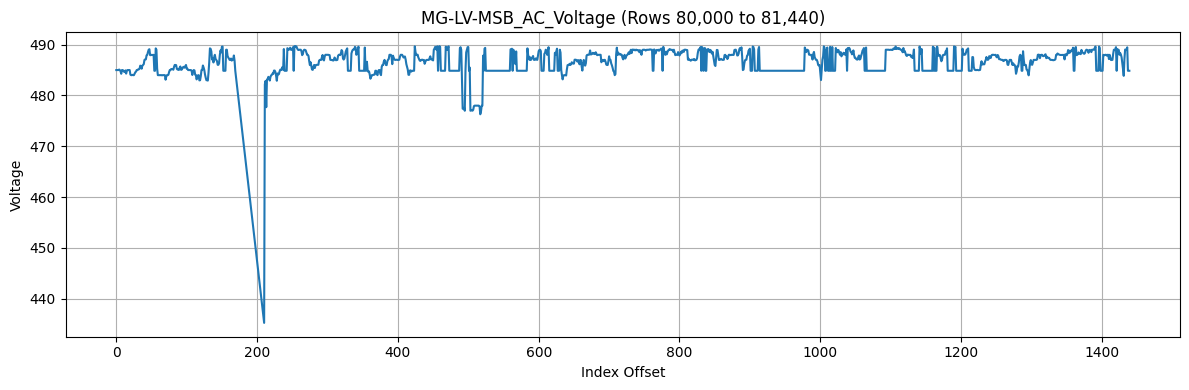

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(aligned_data.iloc[80000:81440]['MG-LV-MSB_AC_Voltage'].values)
plt.title('MG-LV-MSB_AC_Voltage (Rows 80,000 to 81,440)')
plt.xlabel('Index Offset')
plt.ylabel('Voltage')
plt.grid(True)
plt.tight_layout()
plt.show()

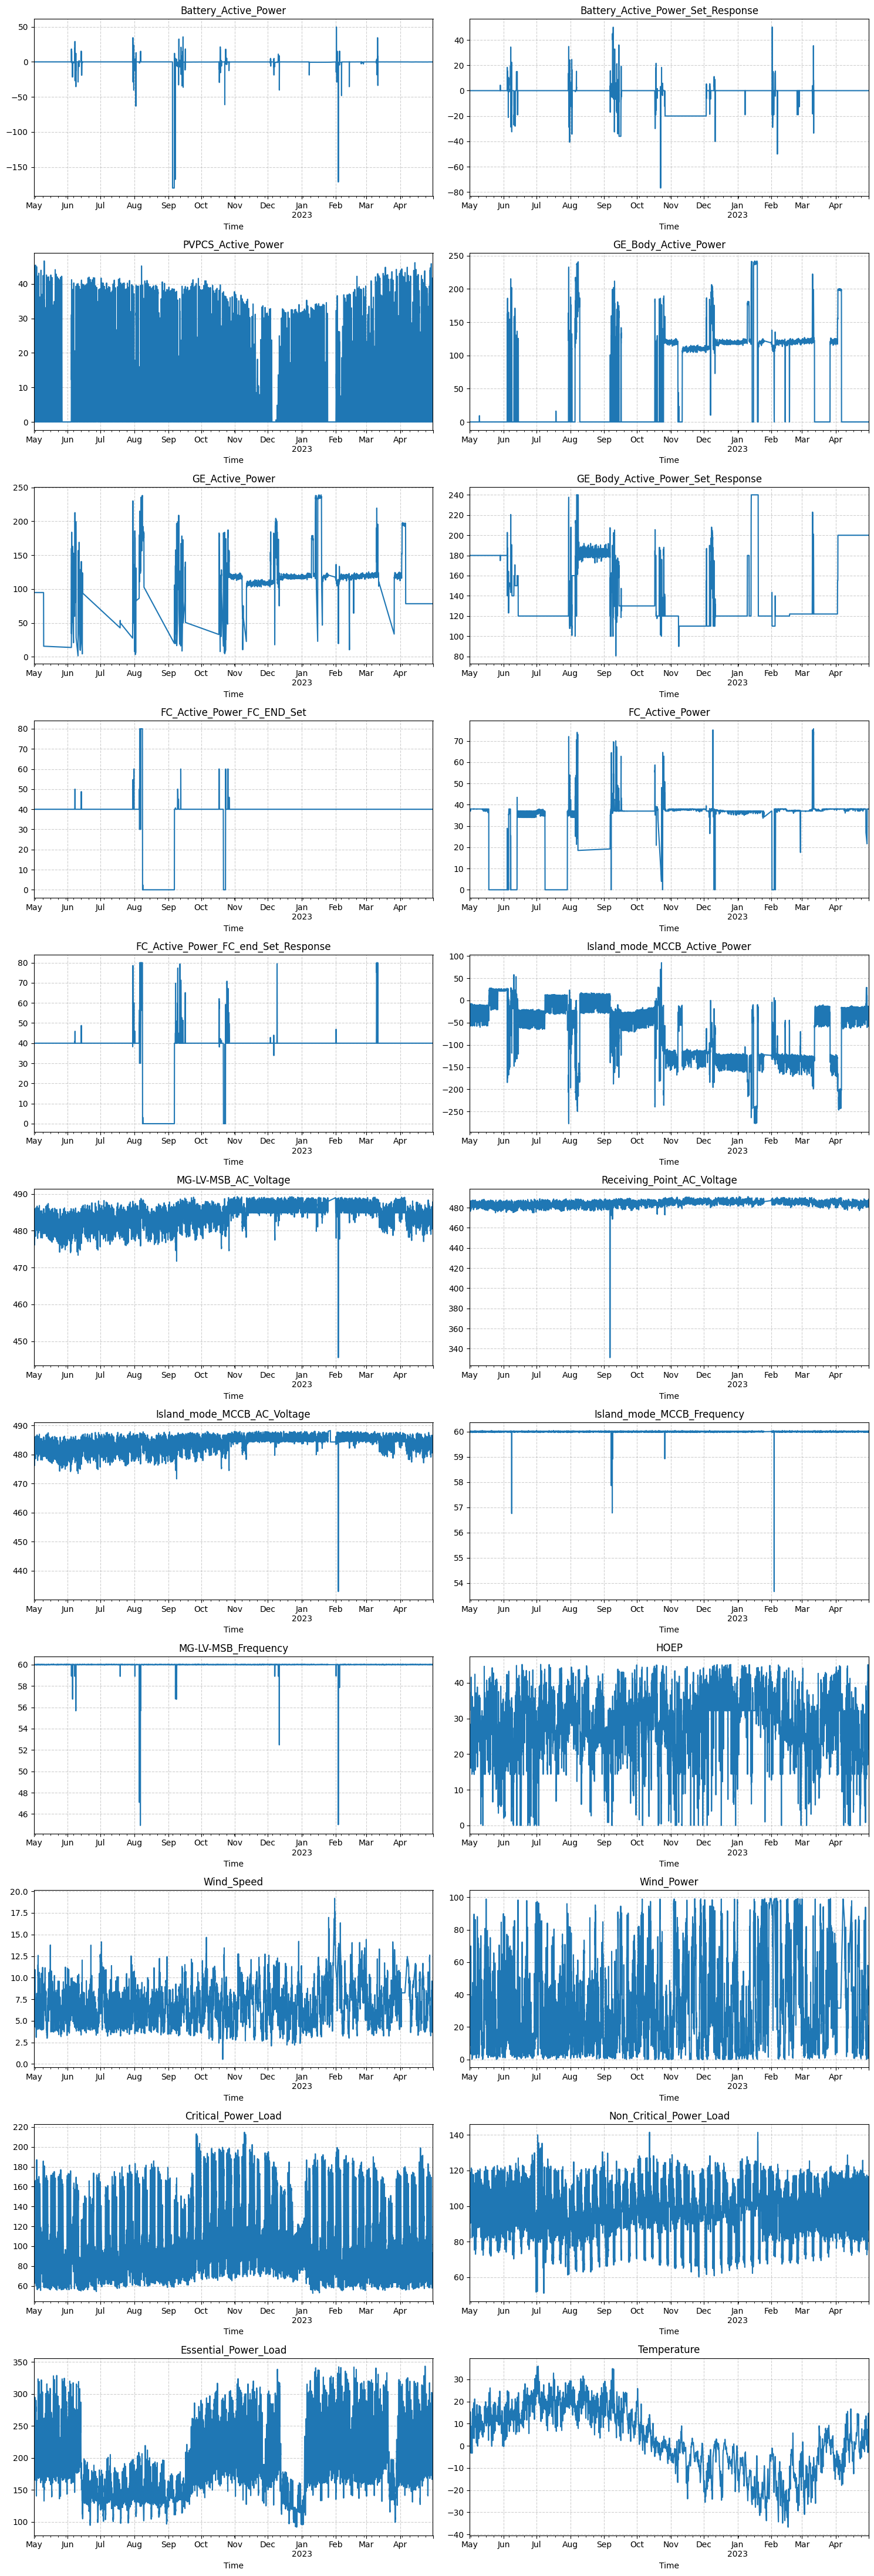

In [31]:
def plot_hourly_variables(aligned_data):
    # Resample to hourly granularity
    hourly_data = aligned_data.resample('h').mean()
    # Get all columns to plot
    columns = hourly_data.columns
    # Create a figure with subplots - calculate rows needed
    n_cols = 2
    n_rows = int(np.ceil(len(columns) / n_cols))
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()  # Flatten to easily iterate
    # Plot each variable
    for i, col in enumerate(columns):
        ax = axes[i]
        hourly_data[col].plot(ax=ax, title=col)
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)
    # Hide any unused subplots
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_hourly_variables(aligned_data)

In [32]:
aligned_data.describe()

,Battery_Active_Power,Battery_Active_Power_Set_Response,PVPCS_Active_Power,GE_Body_Active_Power,GE_Active_Power,GE_Body_Active_Power_Set_Response,FC_Active_Power_FC_END_Set,FC_Active_Power,FC_Active_Power_FC_end_Set_Response,Island_mode_MCCB_Active_Power,...,Island_mode_MCCB_AC_Voltage,Island_mode_MCCB_Frequency,MG-LV-MSB_Frequency,HOEP,Wind_Speed,Wind_Power,Critical_Power_Load,Non_Critical_Power_Load,Essential_Power_Load,Temperature
count,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,...,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000,105120.000000
mean,-1.098502,-2.363224,9.591569,54.189971,85.584735,142.843065,36.904742,30.922280,37.041900,-66.451490,...,483.890751,59.997519,59.978696,27.544659,6.816656,31.151901,113.505561,98.236424,196.829523,2.656830
std,13.200847,7.908350,14.099976,66.459864,45.156594,33.688934,11.764841,13.471280,11.988614,64.895039,...,2.851776,0.189746,0.567960,8.670200,2.374099,28.778198,39.860277,14.672780,54.697715,14.566366
min,-216.000000,-90.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,-306.733333,...,419.200000,34.067667,8.414001,0.000000,0.090000,0.021368,51.589000,47.505667,89.914000,-37.000000
25%,-0.130000,0.000000,0.000000,0.000000,47.413856,120.000000,40.000000,34.301820,40.000000,-123.900000,...,482.266667,59.989001,59.983461,22.950000,4.930000,6.875340,76.690583,87.993250,152.455500,-7.425000
50%,-0.066667,0.000000,0.000000,0.000000,85.413372,122.000000,40.000000,37.000000,40.000000,-45.683333,...,484.347272,60.000667,59.996667,28.670000,6.590000,21.571233,109.155833,101.101000,189.925000,2.300000
75%,0.000000,0.000000,19.000000,119.000000,117.530002,180.000000,40.000000,37.866667,40.000000,-15.733333,...,485.800000,60.012332,60.006999,32.510000,8.290000,49.023625,147.485250,108.499000,238.315000,14.750000
max,81.770000,87.266667,50.366667,261.533333,258.333333,240.000000,80.000000,76.000000,80.000000,150.200000,...,488.300000,60.107001,60.022999,45.140000,19.790000,100.000000,236.131000,164.628000,357.770000,36.500000


### Forecasting solar, wind, and 3 types of loads

Time, temperature, past solar -> next solar

Time, wind speed, past wind -> next wind

Time, past load -> next load

In [33]:
# ts_solar_df = aligned_data[['PVPCS_Active_Power', 'Temperature']]
# ts_wind_df = aligned_data[['Wind_Power', 'Wind_Speed']]
# ts_critical_load_df = aligned_data[['Critical_Power_Load']]
# ts_non_critical_load_df = aligned_data[['Non_Critical_Power_Load']]
# ts_essential_load_df = aligned_data[['Essential_Power_Load']]

In [34]:
# # Hyperparameters
# WINDOW_SIZE = 10
# FORECAST_HORIZON = 1
# BATCH_SIZE = 64
# NUM_EPOCHS = 10
# LEARNING_RATE = 0.001
# TRANSFORMER_DIM = 64
# TRANSFORMER_HEADS = 4
# TRANSFORMER_LAYERS = 2
# DROPOUT_RATE = 0.1
# TEST_SIZE = 0.2

In [35]:
# def add_time_features(df):
#     df = df.copy()  # ensure we're not working with a view
#     if not isinstance(df.index, pd.DatetimeIndex):
#         df.index = pd.to_datetime(df.index)
#     df.loc[:, 'hour'] = df.index.hour
#     df.loc[:, 'day'] = df.index.day
#     df.loc[:, 'month'] = df.index.month
#     df.loc[:, 'day_of_week'] = df.index.dayofweek
#     df.loc[:, 'is_weekend'] = (df.index.dayofweek >= 5).astype(int)
#     return df


# # Apply the function to each dataframe
# ts_solar_df = add_time_features(ts_solar_df)
# ts_wind_df = add_time_features(ts_wind_df)
# ts_critical_load_df = add_time_features(ts_critical_load_df)
# ts_non_critical_load_df = add_time_features(ts_non_critical_load_df)
# ts_essential_load_df = add_time_features(ts_essential_load_df)

In [36]:
# # Prepare solar data
# solar_data = ts_solar_df.copy()
# solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
# solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))

# # Scale solar target column
# solar_data['PVPCS_Active_Power'] = solar_target_scaler.fit_transform(solar_data[['PVPCS_Active_Power']])

# # Create sequences for solar data
# X_solar, y_solar = [], []
# for i in range(len(solar_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_solar.append(solar_data.iloc[i:i+WINDOW_SIZE].values)
#     y_solar.append(solar_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['PVPCS_Active_Power'].values)

# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)

In [37]:
# wind_data = ts_wind_df.copy()
# wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
# wind_data['Wind_Power'] = wind_target_scaler.fit_transform(wind_data[['Wind_Power']])
# wind_feature_cols = ['Wind_Speed']
# wind_data[wind_feature_cols] = wind_feature_scaler.fit_transform(wind_data[wind_feature_cols])
# wind_data['hour'] = wind_data['hour'] / 23.0
# wind_data['day'] = wind_data['day'] / 31.0
# wind_data['month'] = wind_data['month'] / 12.0
# wind_data['day_of_week'] = wind_data['day_of_week'] / 6.0
# X_wind, y_wind = [], []
# for i in range(len(wind_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_wind.append(wind_data.iloc[i:i+WINDOW_SIZE].values)
#     y_wind.append(wind_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Wind_Power'].values)

In [38]:
# critical_data = ts_critical_load_df.copy()
# critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# critical_data['Critical_Power_Load'] = critical_target_scaler.fit_transform(critical_data[['Critical_Power_Load']])
# critical_data['hour'] = critical_data['hour'] / 23.0
# critical_data['day'] = critical_data['day'] / 31.0
# critical_data['month'] = critical_data['month'] / 12.0
# critical_data['day_of_week'] = critical_data['day_of_week'] / 6.0
# X_critical, y_critical = [], []
# for i in range(len(critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_critical.append(critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_critical.append(critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Critical_Power_Load'].values)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)


# non_critical_data = ts_non_critical_load_df.copy()
# non_critical_target_scaler = MinMaxScaler(feature_range=(0, 1))
# non_critical_data['Non_Critical_Power_Load'] = non_critical_target_scaler.fit_transform(non_critical_data[['Non_Critical_Power_Load']])
# non_critical_data['hour'] = non_critical_data['hour'] / 23.0
# non_critical_data['day'] = non_critical_data['day'] / 31.0
# non_critical_data['month'] = non_critical_data['month'] / 12.0
# non_critical_data['day_of_week'] = non_critical_data['day_of_week'] / 6.0
# X_non_critical, y_non_critical = [], []
# for i in range(len(non_critical_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_non_critical.append(non_critical_data.iloc[i:i+WINDOW_SIZE].values)
#     y_non_critical.append(non_critical_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Non_Critical_Power_Load'].values)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)


# essential_data = ts_essential_load_df.copy()
# essential_target_scaler = MinMaxScaler(feature_range=(0, 1))
# essential_data['Essential_Power_Load'] = essential_target_scaler.fit_transform(essential_data[['Essential_Power_Load']])
# essential_data['hour'] = essential_data['hour'] / 23.0
# essential_data['day'] = essential_data['day'] / 31.0
# essential_data['month'] = essential_data['month'] / 12.0
# essential_data['day_of_week'] = essential_data['day_of_week'] / 6.0
# X_essential, y_essential = [], []
# for i in range(len(essential_data) - WINDOW_SIZE - FORECAST_HORIZON + 1):
#     X_essential.append(essential_data.iloc[i:i+WINDOW_SIZE].values)
#     y_essential.append(essential_data.iloc[i+WINDOW_SIZE:i+WINDOW_SIZE+FORECAST_HORIZON]['Essential_Power_Load'].values)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

In [39]:
# X_solar = np.array(X_solar)
# y_solar = np.array(y_solar)
# X_wind = np.array(X_wind)
# y_wind = np.array(y_wind)
# X_critical = np.array(X_critical)
# y_critical = np.array(y_critical)
# X_non_critical = np.array(X_non_critical)
# y_non_critical = np.array(y_non_critical)
# X_essential = np.array(X_essential)
# y_essential = np.array(y_essential)

# print("X_solar:", X_solar.shape, "| y_solar:", y_solar.shape)
# print("X_wind:", X_wind.shape, "| y_wind:", y_wind.shape)
# print("X_critical:", X_critical.shape, "| y_critical:", y_critical.shape)
# print("X_non_critical:", X_non_critical.shape, "| y_non_critical:", y_non_critical.shape)
# print("X_essential:", X_essential.shape, "| y_essential:", y_essential.shape)

# X_solar_train, X_solar_test, y_solar_train, y_solar_test = train_test_split(X_solar, y_solar, test_size=TEST_SIZE, shuffle=False)
# X_wind_train, X_wind_test, y_wind_train, y_wind_test = train_test_split(X_wind, y_wind, test_size=TEST_SIZE, shuffle=False)
# X_critical_train, X_critical_test, y_critical_train, y_critical_test = train_test_split(X_critical, y_critical, test_size=TEST_SIZE, shuffle=False)
# X_non_critical_train, X_non_critical_test, y_non_critical_train, y_non_critical_test = train_test_split(X_non_critical, y_non_critical, test_size=TEST_SIZE, shuffle=False)
# X_essential_train, X_essential_test, y_essential_train, y_essential_test = train_test_split(X_essential, y_essential, test_size=TEST_SIZE, shuffle=False)

In [40]:
# # Create PyTorch dataset class
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [41]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.X)
    
#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

In [42]:
# solar_train_dataset = TimeSeriesDataset(X_solar_train, y_solar_train)
# solar_test_dataset = TimeSeriesDataset(X_solar_test, y_solar_test)
# wind_train_dataset = TimeSeriesDataset(X_wind_train, y_wind_train)
# wind_test_dataset = TimeSeriesDataset(X_wind_test, y_wind_test)
# critical_train_dataset = TimeSeriesDataset(X_critical_train, y_critical_train)
# critical_test_dataset = TimeSeriesDataset(X_critical_test, y_critical_test)
# non_critical_train_dataset = TimeSeriesDataset(X_non_critical_train, y_non_critical_train)
# non_critical_test_dataset = TimeSeriesDataset(X_non_critical_test, y_non_critical_test)
# essential_train_dataset = TimeSeriesDataset(X_essential_train, y_essential_train)
# essential_test_dataset = TimeSeriesDataset(X_essential_test, y_essential_test)

In [43]:
# solar_train_loader = DataLoader(solar_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# solar_test_loader = DataLoader(solar_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# wind_train_loader = DataLoader(wind_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# wind_test_loader = DataLoader(wind_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# critical_train_loader = DataLoader(critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# critical_test_loader = DataLoader(critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# non_critical_train_loader = DataLoader(non_critical_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# non_critical_test_loader = DataLoader(non_critical_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# essential_train_loader = DataLoader(essential_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# essential_test_loader = DataLoader(essential_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [44]:
# # Define Transformer model architecture
# class TimeSeriesTransformer(nn.Module):
#     def __init__(self, input_dim, output_dim, d_model=TRANSFORMER_DIM, nhead=TRANSFORMER_HEADS, 
#                  num_layers=TRANSFORMER_LAYERS, dropout=DROPOUT_RATE):
#         super(TimeSeriesTransformer, self).__init__()
        
#         self.encoder = nn.Linear(input_dim, d_model)
#         self.pos_encoder = nn.Parameter(torch.zeros(WINDOW_SIZE, d_model))
        
#         encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
#                                                   dropout=dropout, batch_first=True)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
#         self.decoder = nn.Linear(d_model, output_dim)
        
#     def forward(self, x):
#         # x shape: [batch_size, seq_len, input_dim]
#         x = self.encoder(x)  # [batch_size, seq_len, d_model]
#         x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
#         x = self.transformer_encoder(x)
#         x = x[:, -1, :]  # Use the last sequence element for prediction
#         x = self.decoder(x)  # [batch_size, output_dim]
#         return x

In [45]:
# solar_model = TimeSeriesTransformer(input_dim=X_solar.shape[2], output_dim=FORECAST_HORIZON)
# wind_model = TimeSeriesTransformer(input_dim=X_wind.shape[2], output_dim=FORECAST_HORIZON)
# critical_model = TimeSeriesTransformer(input_dim=X_critical.shape[2], output_dim=FORECAST_HORIZON)
# non_critical_model = TimeSeriesTransformer(input_dim=X_non_critical.shape[2], output_dim=FORECAST_HORIZON)
# essential_model = TimeSeriesTransformer(input_dim=X_essential.shape[2], output_dim=FORECAST_HORIZON)

In [46]:
# solar_model = solar_model.to(device)
# wind_model = wind_model.to(device)
# critical_model = critical_model.to(device)
# non_critical_model = non_critical_model.to(device)
# essential_model = essential_model.to(device)

In [47]:
# criterion = nn.MSELoss()
# solar_optimizer = optim.Adam(solar_model.parameters(), lr=LEARNING_RATE)
# wind_optimizer = optim.Adam(wind_model.parameters(), lr=LEARNING_RATE)
# critical_optimizer = optim.Adam(critical_model.parameters(), lr=LEARNING_RATE)
# non_critical_optimizer = optim.Adam(non_critical_model.parameters(), lr=LEARNING_RATE)
# essential_optimizer = optim.Adam(essential_model.parameters(), lr=LEARNING_RATE)

In [48]:
# # Train solar model
# solar_model.train()
# solar_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in solar_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         solar_optimizer.zero_grad()
#         y_pred = solar_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         solar_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(solar_train_loader)
#     solar_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Solar Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [49]:
# # Train wind model
# wind_model.train()
# wind_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in wind_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         wind_optimizer.zero_grad()
#         y_pred = wind_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         wind_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(wind_train_loader)
#     wind_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Wind Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')

In [50]:
# # Train critical load model
# critical_model.train()
# critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         critical_optimizer.zero_grad()
#         y_pred = critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(critical_train_loader)
#     critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [51]:
# # Train non-critical load model
# non_critical_model.train()
# non_critical_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in non_critical_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         non_critical_optimizer.zero_grad()
#         y_pred = non_critical_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         non_critical_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(non_critical_train_loader)
#     non_critical_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Non-Critical Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [52]:
# # Train essential load model
# essential_model.train()
# essential_train_losses = []

# for epoch in range(NUM_EPOCHS):
#     epoch_loss = 0
#     for X_batch, y_batch in essential_train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         essential_optimizer.zero_grad()
#         y_pred = essential_model(X_batch)
#         loss = criterion(y_pred, y_batch)
#         loss.backward()
#         essential_optimizer.step()
#         epoch_loss += loss.item()
    
#     epoch_loss /= len(essential_train_loader)
#     essential_train_losses.append(epoch_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Essential Load Model - Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}')


In [53]:
# # Test solar model
# solar_model.eval()
# solar_test_loss = 0
# solar_predictions = []
# solar_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in solar_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = solar_model(X_batch)
#         solar_test_loss += criterion(y_pred, y_batch).item()
#         solar_predictions.append(y_pred.cpu().numpy())
#         solar_actuals.append(y_batch.cpu().numpy())

# solar_test_loss /= len(solar_test_loader)
# solar_predictions = np.vstack(solar_predictions)
# solar_actuals = np.vstack(solar_actuals)

In [54]:
# # Inverse transform solar predictions and actuals
# solar_predictions_reshaped = solar_predictions.reshape(-1, 1)
# solar_actuals_reshaped = solar_actuals.reshape(-1, 1)
# solar_predictions = solar_target_scaler.inverse_transform(solar_predictions_reshaped).reshape(solar_predictions.shape)
# solar_actuals = solar_target_scaler.inverse_transform(solar_actuals_reshaped).reshape(solar_actuals.shape)

# print(f'Solar Model - Test Loss: {solar_test_loss:.4f}')

In [55]:
# # Test wind model
# wind_model.eval()
# wind_test_loss = 0
# wind_predictions = []
# wind_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in wind_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = wind_model(X_batch)
#         wind_test_loss += criterion(y_pred, y_batch).item()
#         wind_predictions.append(y_pred.cpu().numpy())
#         wind_actuals.append(y_batch.cpu().numpy())

# wind_test_loss /= len(wind_test_loader)
# wind_predictions = np.vstack(wind_predictions)
# wind_actuals = np.vstack(wind_actuals)

In [56]:
# # Inverse transform wind predictions and actuals
# wind_predictions_reshaped = wind_predictions.reshape(-1, 1)
# wind_actuals_reshaped = wind_actuals.reshape(-1, 1)
# wind_predictions = wind_target_scaler.inverse_transform(wind_predictions_reshaped).reshape(wind_predictions.shape)
# wind_actuals = wind_target_scaler.inverse_transform(wind_actuals_reshaped).reshape(wind_actuals.shape)
# print(f'Wind Model - Test Loss: {wind_test_loss:.4f}')

In [57]:
# # Test critical load model
# critical_model.eval()
# critical_test_loss = 0
# critical_predictions = []
# critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = critical_model(X_batch)
#         critical_test_loss += criterion(y_pred, y_batch).item()
#         critical_predictions.append(y_pred.cpu().numpy())
#         critical_actuals.append(y_batch.cpu().numpy())

# critical_test_loss /= len(critical_test_loader)
# critical_predictions = np.vstack(critical_predictions)
# critical_actuals = np.vstack(critical_actuals)

In [58]:
# # Inverse transform critical load predictions and actuals
# critical_predictions_reshaped = critical_predictions.reshape(-1, 1)
# critical_actuals_reshaped = critical_actuals.reshape(-1, 1)
# critical_predictions = critical_target_scaler.inverse_transform(critical_predictions_reshaped).reshape(critical_predictions.shape)
# critical_actuals = critical_target_scaler.inverse_transform(critical_actuals_reshaped).reshape(critical_actuals.shape)
# print(f'Critical Load Model - Test Loss: {critical_test_loss:.4f}')

In [59]:
# # Test non-critical load model
# non_critical_model.eval()
# non_critical_test_loss = 0
# non_critical_predictions = []
# non_critical_actuals = []

# with torch.no_grad():
#     for X_batch, y_batch in non_critical_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = non_critical_model(X_batch)
#         non_critical_test_loss += criterion(y_pred, y_batch).item()
#         non_critical_predictions.append(y_pred.cpu().numpy())
#         non_critical_actuals.append(y_batch.cpu().numpy())

# non_critical_test_loss /= len(non_critical_test_loader)
# non_critical_predictions = np.vstack(non_critical_predictions)
# non_critical_actuals = np.vstack(non_critical_actuals)

In [60]:
# # Inverse transform non-critical load predictions and actuals
# non_critical_predictions_reshaped = non_critical_predictions.reshape(-1, 1)
# non_critical_actuals_reshaped = non_critical_actuals.reshape(-1, 1)
# non_critical_predictions = non_critical_target_scaler.inverse_transform(non_critical_predictions_reshaped).reshape(non_critical_predictions.shape)
# non_critical_actuals = non_critical_target_scaler.inverse_transform(non_critical_actuals_reshaped).reshape(non_critical_actuals.shape)

# print(f'Non-Critical Load Model - Test Loss: {non_critical_test_loss:.4f}')

In [61]:
# # Test essential load model
# essential_model.eval()
# essential_test_loss = 0
# essential_predictions = []
# essential_actuals = []
# with torch.no_grad():
#     for X_batch, y_batch in essential_test_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         y_pred = essential_model(X_batch)
#         essential_test_loss += criterion(y_pred, y_batch).item()
#         essential_predictions.append(y_pred.cpu().numpy())
#         essential_actuals.append(y_batch.cpu().numpy())
# essential_test_loss /= len(essential_test_loader)
# essential_predictions = np.vstack(essential_predictions)
# essential_actuals = np.vstack(essential_actuals)

In [62]:
# # Inverse transform essential load predictions and actuals
# essential_predictions_reshaped = essential_predictions.reshape(-1, 1)
# essential_actuals_reshaped = essential_actuals.reshape(-1, 1)
# essential_predictions = essential_target_scaler.inverse_transform(essential_predictions_reshaped).reshape(essential_predictions.shape)
# essential_actuals = essential_target_scaler.inverse_transform(essential_actuals_reshaped).reshape(essential_actuals.shape)

# print(f'Essential Load Model - Test Loss: {essential_test_loss:.4f}')

In [63]:
# # Plot training losses
# plt.figure(figsize=(12, 8))
# plt.plot(solar_train_losses, label='Solar')
# plt.plot(wind_train_losses, label='Wind')
# plt.plot(critical_train_losses, label='Critical Load')
# plt.plot(non_critical_train_losses, label='Non-Critical Load')
# plt.plot(essential_train_losses, label='Essential Load')
# plt.title('Training Loss Over Time')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

# solar_mse = mean_squared_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_rmse = np.sqrt(solar_mse)
# solar_mae = mean_absolute_error(solar_actuals.flatten(), solar_predictions.flatten())
# solar_r2 = r2_score(solar_actuals.flatten(), solar_predictions.flatten())
# wind_mse = mean_squared_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_rmse = np.sqrt(wind_mse)
# wind_mae = mean_absolute_error(wind_actuals.flatten(), wind_predictions.flatten())
# wind_r2 = r2_score(wind_actuals.flatten(), wind_predictions.flatten())
# critical_mse = mean_squared_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_rmse = np.sqrt(critical_mse)
# critical_mae = mean_absolute_error(critical_actuals.flatten(), critical_predictions.flatten())
# critical_r2 = r2_score(critical_actuals.flatten(), critical_predictions.flatten())
# non_critical_mse = mean_squared_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_rmse = np.sqrt(non_critical_mse)
# non_critical_mae = mean_absolute_error(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# non_critical_r2 = r2_score(non_critical_actuals.flatten(), non_critical_predictions.flatten())
# essential_mse = mean_squared_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_rmse = np.sqrt(essential_mse)
# essential_mae = mean_absolute_error(essential_actuals.flatten(), essential_predictions.flatten())
# essential_r2 = r2_score(essential_actuals.flatten(), essential_predictions.flatten())

# print("Solar Model Metrics:")
# print(f"MSE: {solar_mse:.4f}, RMSE: {solar_rmse:.4f}, MAE: {solar_mae:.4f}, R²: {solar_r2:.4f}")
# print("Wind Model Metrics:")
# print(f"MSE: {wind_mse:.4f}, RMSE: {wind_rmse:.4f}, MAE: {wind_mae:.4f}, R²: {wind_r2:.4f}")
# print("Critical Load Model Metrics:")
# print(f"MSE: {critical_mse:.4f}, RMSE: {critical_rmse:.4f}, MAE: {critical_mae:.4f}, R²: {critical_r2:.4f}")
# print("Non-Critical Load Model Metrics:")
# print(f"MSE: {non_critical_mse:.4f}, RMSE: {non_critical_rmse:.4f}, MAE: {non_critical_mae:.4f}, R²: {non_critical_r2:.4f}")
# print("Essential Load Model Metrics:")
# print(f"MSE: {essential_mse:.4f}, RMSE: {essential_rmse:.4f}, MAE: {essential_mae:.4f}, R²: {essential_r2:.4f}")

In [64]:
# # Create a directory for saved models if it doesn't exist
# save_dir = "saved_models"
# os.makedirs(save_dir, exist_ok=True)

# # Generate timestamp for unique filenames
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # Move models to CPU before saving if they were on GPU
# solar_model_cpu = solar_model.to('cpu')
# wind_model_cpu = wind_model.to('cpu')
# critical_model_cpu = critical_model.to('cpu')
# non_critical_model_cpu = non_critical_model.to('cpu')
# essential_model_cpu = essential_model.to('cpu')

# # Save model state dictionaries
# torch.save(solar_model_cpu.state_dict(), f"{save_dir}/solar_model.pt")
# torch.save(wind_model_cpu.state_dict(), f"{save_dir}/wind_model.pt")
# torch.save(critical_model_cpu.state_dict(), f"{save_dir}/critical_load_model.pt")
# torch.save(non_critical_model_cpu.state_dict(), f"{save_dir}/non_critical_load_model.pt")
# torch.save(essential_model_cpu.state_dict(), f"{save_dir}/essential_load_model.pt")
# print(f"All models successfully saved in {save_dir} directory")

In [65]:
# sample_size = 3
# time_steps = np.arange(sample_size)
# plt.figure(figsize=(20, 15))

# # 1. Solar Power Predictions
# plt.subplot(3, 2, 1)
# plt.plot(time_steps, solar_actuals[:sample_size].flatten(), 'b-', label='Actual Solar Power')
# plt.plot(time_steps, solar_predictions[:sample_size].flatten(), 'r--', label='Predicted Solar Power')
# plt.title('Solar Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Solar Power')
# plt.legend()
# plt.grid(True)

# # 2. Wind Power Predictions
# plt.subplot(3, 2, 2)
# plt.plot(time_steps, wind_actuals[:sample_size].flatten(), 'b-', label='Actual Wind Power')
# plt.plot(time_steps, wind_predictions[:sample_size].flatten(), 'r--', label='Predicted Wind Power')
# plt.title('Wind Power: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Wind Power')
# plt.legend()
# plt.grid(True)

# # 3. Critical Load Predictions
# plt.subplot(3, 2, 3)
# plt.plot(time_steps, critical_actuals[:sample_size].flatten(), 'b-', label='Actual Critical Load')
# plt.plot(time_steps, critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Critical Load')
# plt.title('Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Critical Load')
# plt.legend()
# plt.grid(True)

# # 4. Non-Critical Load Predictions
# plt.subplot(3, 2, 4)
# plt.plot(time_steps, non_critical_actuals[:sample_size].flatten(), 'b-', label='Actual Non-Critical Load')
# plt.plot(time_steps, non_critical_predictions[:sample_size].flatten(), 'r--', label='Predicted Non-Critical Load')
# plt.title('Non-Critical Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Non-Critical Load')
# plt.legend()
# plt.grid(True)

# # 5. Essential Load Predictions
# plt.subplot(3, 2, 5)
# plt.plot(time_steps, essential_actuals[:sample_size].flatten(), 'b-', label='Actual Essential Load')
# plt.plot(time_steps, essential_predictions[:sample_size].flatten(), 'r--', label='Predicted Essential Load')
# plt.title('Essential Load: Actual vs Predicted')
# plt.xlabel('Time Steps')
# plt.ylabel('Essential Load')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.suptitle('Actual vs Predicted Values for All Models', fontsize=16)
# plt.subplots_adjust(top=0.92)
# plt.show()

### PPO Model

In [66]:
# PPO training setup
learning_rate = 0.0075
n_steps = 2048
batch_size = 128
n_epochs = 15
gamma = 0.99
gae_lambda = 0.95
clip_range = 0.2
clip_range_vf = 0.2
normalize_advantage = True
ent_coef = 0.03
verbose = 1
device = "cuda"
policy_net_arch = dict(pi=[512, 128, 64], vf=[512, 128, 64])
activation_fn = torch.nn.ReLU

# Reward function weights
GRID_IMPORT_COST_FACTOR = 0.3  # Slightly increased
GRID_EXPORT_REVENUE_FACTOR = 0.15

RENEWABLE_REWARD_COEFF = 0.8  # Increased to emphasize renewable usage
GENERATOR_FUEL_COST = 1.2  # $/kWh
FUEL_CELL_COST = 1.2  # $/kWh

BATTERY_SOC_PENALTY_MULTIPLIER = 8.0 # Penalty for battery going too low
BATTERY_VIOLATION_PENALTY = 12.0  # Penalty for trying to over-discharge/charge

CRITICAL_LOAD_PENALTY = 15.0  # Penalty multiplier for unmet critical load
ESSENTIAL_LOAD_PENALTY = 10.0 # Penality for unmet essential load
NON_CRITICAL_LOAD_PENALTY = 6.0  # Penalty multiplier for unmet non-critical load
LOAD_SHEDDING_PENALTY = 3.5

GRID_CONNECTION_PENALTY = 1.5
BATTERY_DISCHARGE_REWARD_COEFF = 0.6
FOSSIL_FUEL_EFFICIENCY_COEFF = 1.8
BATTERY_HIGH_SOC_PENALTY = 2.0
BATTERY_TARGET_REWARD = 2.5

REWARD_SCALING_FACTOR = 10000.0

In [67]:
# # Define Transformer model architecture
# class TimeSeriesTransformer(nn.Module):
#     def __init__(self, input_dim, output_dim, d_model=TRANSFORMER_DIM, nhead=TRANSFORMER_HEADS, 
#                  num_layers=TRANSFORMER_LAYERS, dropout=DROPOUT_RATE):
#         super(TimeSeriesTransformer, self).__init__()
        
#         self.encoder = nn.Linear(input_dim, d_model)
#         self.pos_encoder = nn.Parameter(torch.zeros(WINDOW_SIZE, d_model))
        
#         encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
#                                                   dropout=dropout, batch_first=True)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
#         self.decoder = nn.Linear(d_model, output_dim)
        
#     def forward(self, x):
#         # x shape: [batch_size, seq_len, input_dim]
#         x = self.encoder(x)  # [batch_size, seq_len, d_model]
#         x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
#         x = self.transformer_encoder(x)
#         x = x[:, -1, :]  # Use the last sequence element for prediction
#         x = self.decoder(x)  # [batch_size, output_dim]
#         return x

In [70]:
class MicrogridEnv(gym.Env):
    """
    This environment simulates a microgrid with:
    - 1. Solar PV generation
    - 2. Wind generation
    - 3. 160 kWh Lead Acid Battery Storage
    - 4. Fuel generator engine
    - 5. Fuel cell
    - 6. Grid connection
    - 7. Critical, essential, and non-critical loads
    - 8. DC/AC inverters for power conversion
    """

    def __init__(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data, episode_length=288):  # 288 = 24 hours at 5-min intervals (1440 / 5 = 288)
        super(MicrogridEnv, self).__init__()


        # Time series model hyperparameters
        self.WINDOW_SIZE = 10
        self.TRANSFORMER_DIM = 64
        self.TRANSFORMER_HEADS = 4
        self.TRANSFORMER_LAYERS = 2
        self.DROPOUT_RATE = 0.1
        self.FORECAST_HORIZON = 1

        
        # Preprocess and align all data to 5-minute intervals
        self.data = self._preprocess_data(mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data)

        # Device configuration
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Normalization factors
        self.max_battery_power = self.data['Battery_Active_Power'].abs().max()
        self.max_pv_power_actual = self.data['PVPCS_Active_Power'].abs().max()
        self.max_generator_power_actual = self.data['GE_Active_Power'].abs().max()
        self.max_fuel_cell_power_actual = self.data['FC_Active_Power'].abs().max()
        self.max_grid_power = self.data['Island_mode_MCCB_Active_Power'].abs().max()
        self.max_grid_voltage = self.data['MG-LV-MSB_AC_Voltage'].abs().max()
        self.max_grid_frequency = self.data['MG-LV-MSB_Frequency'].abs().max()
        self.max_energy_price = self.data['HOEP'].max() if 'HOEP' in self.data.columns else 100.0
        self.max_wind_speed = self.data['Wind_Speed'].abs().max() if 'Wind_Speed' in self.data.columns else 25.0
        self.max_wind_power = self.data['Wind_Power'].abs().max() if 'Wind_Power' in self.data.columns else 50.0
        self.max_critical_load = self.data['Critical_Power_Load'].abs().max() if 'Critical_Power_Load' in self.data.columns else 50.0
        self.max_essential_load = self.data['Essential_Power_Load'].abs().max() if 'Essential_Power_Load' in self.data.columns else 50.0
        self.max_non_critical_load = self.data['Non_Critical_Power_Load'].abs().max() if 'Non_Critical_Power_Load' in self.data.columns else 50.0
        self.max_temperature = self.data['Temperature'].abs().max() if 'Temperature' in self.data.columns else 40.0
        
        # Battery parameters
        self.battery_capacity = 160.0  # kWh (this is fact)
        
        self.min_battery_soc = 0.2  # Minimum allowable state of charge (hyperparameter)
        # 5.3 hours to fully charge/discharge
        self.max_battery_charge_rate = 30.0  # kW (this is assumed)
        self.max_battery_discharge_rate = 30.0  # kW (this is assumed)
        self.battery_charging_efficiency = 0.95 # (this is assumed)
        
        # Efficiencies (for all conversions between DC and AC + batteries)
        self.battery_discharging_efficiency = 0.95 # (this is assumed)
        self.dc_ac_inverter_efficiency = 0.95
        
        # Component power ratings
        self.max_pv_power = 50.0  # kW (this is fact)
        self.max_wind_power = 50.0  # kW (this is assumed, and it may not be credible!)
        self.max_generator_power = 240.0  # kW  (this is fact)
        self.min_generator_power = 20.0  # kW for stable operation (assumed)
        self.max_fuel_cell_power = 80.0  # kW (this is fact)
        self.min_fuel_cell_power = 5.0  # kW for stable operation (assumed)
        
        # Initial state
        self.battery_soc = 0.5  # Start at 50% capacity
        self.current_step = 0
        self.episode_length = episode_length
        self.start_idx = 0
        
        # Define action and observation spaces
        # Action space is described in the step() function
        self.action_space = spaces.Box(
            low=np.array([-1.0, 0.0, 0.0, 0.0, 0.0]),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # Observation state variable space
        # 27 features in our state space
        # Described in the get_observation() function
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(32,),  
            dtype=np.float32
        )

        self.RENEWABLE_REWARD_COEFF = RENEWABLE_REWARD_COEFF
        self.GRID_IMPORT_COST_FACTOR = GRID_IMPORT_COST_FACTOR
        self.GRID_EXPORT_REVENUE_FACTOR = GRID_EXPORT_REVENUE_FACTOR
        self.GENERATOR_FUEL_COST = GENERATOR_FUEL_COST
        self.FUEL_CELL_COST = FUEL_CELL_COST
        self.BATTERY_SOC_PENALTY_MULTIPLIER = BATTERY_SOC_PENALTY_MULTIPLIER
        self.REWARD_SCALING_FACTOR = REWARD_SCALING_FACTOR
        self.BATTERY_VIOLATION_PENALTY = BATTERY_VIOLATION_PENALTY
        self.CRITICAL_LOAD_PENALTY = CRITICAL_LOAD_PENALTY
        self.NON_CRITICAL_LOAD_PENALTY = NON_CRITICAL_LOAD_PENALTY
        self.ESSENTIAL_LOAD_PENALTY = ESSENTIAL_LOAD_PENALTY
        self.GRID_CONNECTION_PENALTY = GRID_CONNECTION_PENALTY
        self.BATTERY_DISCHARGE_REWARD_COEFF = BATTERY_DISCHARGE_REWARD_COEFF
        self.FOSSIL_FUEL_EFFICIENCY_COEFF = FOSSIL_FUEL_EFFICIENCY_COEFF
        self.BATTERY_HIGH_SOC_PENALTY = BATTERY_HIGH_SOC_PENALTY
        self.LOAD_SHEDDING_PENALTY_COEFF = LOAD_SHEDDING_PENALTY
        self.FOSSIL_FUEL_EFFICIENCY_REWARD = FOSSIL_FUEL_EFFICIENCY_COEFF
        self.BATTERY_TARGET_REWARD = BATTERY_TARGET_REWARD

        
        # Initialize scalers for data normalization
        self._initialize_scalers()
        
        # Initialize transformer models
        self._initialize_forecasting_models()

    def _initialize_scalers(self):
        """Initialize scalers for normalizing time series data"""
        # Create and fit scalers for each data type
        self.solar_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.solar_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_target_scaler = MinMaxScaler(feature_range=(0, 1))
        self.wind_feature_scaler = MinMaxScaler(feature_range=(0, 1))
        self.critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.non_critical_load_scaler = MinMaxScaler(feature_range=(0, 1))
        self.essential_load_scaler = MinMaxScaler(feature_range=(0, 1))
        
        # Fit scalers on the entire dataset
        self.solar_target_scaler.fit(self.data[['PVPCS_Active_Power']])
        self.wind_target_scaler.fit(self.data[['Wind_Power']])
        self.critical_load_scaler.fit(self.data[['Critical_Power_Load']])
        self.non_critical_load_scaler.fit(self.data[['Non_Critical_Power_Load']])
        self.essential_load_scaler.fit(self.data[['Essential_Power_Load']])
        
        # Feature scalers
        self.solar_feature_scaler.fit(self.data[['Temperature']])
        self.wind_feature_scaler.fit(self.data[['Wind_Speed']])

    def _initialize_forecasting_models(self):
        """Initialize the transformer-based forecasting models"""
        class TimeSeriesTransformer(nn.Module):
            def __init__(self, input_dim, output_dim, d_model=self.TRANSFORMER_DIM, 
                        nhead=self.TRANSFORMER_HEADS, num_layers=self.TRANSFORMER_LAYERS, 
                        dropout=self.DROPOUT_RATE, window_size=self.WINDOW_SIZE):
                super(TimeSeriesTransformer, self).__init__()
                
                self.encoder = nn.Linear(input_dim, d_model)
                self.pos_encoder = nn.Parameter(torch.zeros(window_size, d_model))
                
                encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                          dropout=dropout, batch_first=True)
                self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
                self.decoder = nn.Linear(d_model, output_dim)
                
            def forward(self, x):
                # x shape: [batch_size, seq_len, input_dim]
                x = self.encoder(x)  # [batch_size, seq_len, d_model]
                x = x + self.pos_encoder.unsqueeze(0)  # Add positional encoding
                x = self.transformer_encoder(x)
                x = x[:, -1, :]  # Use the last sequence element for prediction
                x = self.decoder(x)  # [batch_size, output_dim]
                return x

        # Create the models
        # Solar model (inputs: past solar + temperature + time features)
        solar_input_dim = 7  # PVPCS_Active_Power, Temperature, + 4 time features
        self.solar_model = TimeSeriesTransformer(solar_input_dim, self.FORECAST_HORIZON).to(self.device)
        
        # Wind model (inputs: past wind + wind speed + time features)
        wind_input_dim = 7  # Wind_Power, Wind_Speed, + 4 time features
        self.wind_model = TimeSeriesTransformer(wind_input_dim, self.FORECAST_HORIZON).to(self.device)
        
        # Load models (inputs: past load + time features)
        load_input_dim = 6  # Load value + 4 time features
        self.critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.non_critical_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        self.essential_load_model = TimeSeriesTransformer(load_input_dim, self.FORECAST_HORIZON).to(self.device)
        
        # Load pre-trained model weights if available
        try:
            self.solar_model.load_state_dict(torch.load('saved_models/solar_model.pt', map_location=self.device))
            self.wind_model.load_state_dict(torch.load('saved_models/wind_model.pt', map_location=self.device))
            self.critical_load_model.load_state_dict(torch.load('saved_models/critical_load_model.pt', map_location=self.device))
            self.non_critical_load_model.load_state_dict(torch.load('saved_models/non_critical_load_model.pt', map_location=self.device))
            self.essential_load_model.load_state_dict(torch.load('saved_models/essential_load_model.pt', map_location=self.device))
            print("Successfully loaded pre-trained forecasting models")
        except Exception as e:
            print(f"Could not load pre-trained models: {e}. Using untrained models.")
        
        # Set models to evaluation mode
        self.solar_model.eval()
        self.wind_model.eval()
        self.critical_load_model.eval()
        self.non_critical_load_model.eval()
        self.essential_load_model.eval()


    
    def _extract_time_features(self, timestamp):
        """Extract time features for forecasting models"""
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0
        month_of_year = (timestamp.month - 1) / 11.0
        return np.array([sin_hour, cos_hour, day_of_week, month_of_year])



    def _generate_forecasts(self, idx):
        """Generate forecasts for the next timestep using transformer models"""
        # Check if we have enough history
        if idx < self.WINDOW_SIZE:
            return {
                'solar_forecast': 0,
                'wind_forecast': 0,
            }
        
        with torch.no_grad():
            # Prepare historical data window
            history_indices = range(idx - self.WINDOW_SIZE, idx)
            
            # SOLAR FORECAST
            solar_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                solar_power = self.data.iloc[hist_idx]['PVPCS_Active_Power']
                solar_power_norm = self.solar_target_scaler.transform([[solar_power]])[0][0]
                
                temperature = self.data.iloc[hist_idx]['Temperature']
                temperature_norm = self.solar_feature_scaler.transform([[temperature]])[0][0]
                
                # Time features matching training data
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                
                solar_seq[i] = [solar_power_norm, temperature_norm, hour, day, month, day_of_week, is_weekend]
            
            solar_tensor = torch.tensor(solar_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            solar_pred = self.solar_model(solar_tensor).cpu().numpy()[0][0]
            solar_forecast = self.solar_target_scaler.inverse_transform([[solar_pred]])[0][0]
            
            # WIND FORECAST
            wind_seq = np.zeros((self.WINDOW_SIZE, 7))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                wind_power = self.data.iloc[hist_idx]['Wind_Power']
                wind_power_norm = self.wind_target_scaler.transform([[wind_power]])[0][0]
                
                wind_speed = self.data.iloc[hist_idx]['Wind_Speed']
                wind_speed_norm = self.wind_feature_scaler.transform([[wind_speed]])[0][0]
                
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                
                wind_seq[i] = [wind_power_norm, wind_speed_norm, hour, day, month, day_of_week, is_weekend]
            
            wind_tensor = torch.tensor(wind_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            wind_pred = self.wind_model(wind_tensor).cpu().numpy()[0][0]
            wind_forecast = self.wind_target_scaler.inverse_transform([[wind_pred]])[0][0]
            
            # CRITICAL LOAD FORECAST
            critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                critical_load = self.data.iloc[hist_idx]['Critical_Power_Load']
                critical_load_norm = self.critical_load_scaler.transform([[critical_load]])[0][0]
                
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                
                critical_seq[i] = [critical_load_norm, hour, day, month, day_of_week, is_weekend]
            
            critical_tensor = torch.tensor(critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            critical_pred = self.critical_load_model(critical_tensor).cpu().numpy()[0][0]
            critical_forecast = self.critical_load_scaler.inverse_transform([[critical_pred]])[0][0]
            
            # NON-CRITICAL LOAD FORECAST
            non_critical_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                non_critical_load = self.data.iloc[hist_idx]['Non_Critical_Power_Load']
                non_critical_load_norm = self.non_critical_load_scaler.transform([[non_critical_load]])[0][0]
                
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                
                non_critical_seq[i] = [non_critical_load_norm, hour, day, month, day_of_week, is_weekend]
            
            non_critical_tensor = torch.tensor(non_critical_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            non_critical_pred = self.non_critical_load_model(non_critical_tensor).cpu().numpy()[0][0]
            non_critical_forecast = self.non_critical_load_scaler.inverse_transform([[non_critical_pred]])[0][0]
            
            # ESSENTIAL LOAD FORECAST
            essential_seq = np.zeros((self.WINDOW_SIZE, 6))
            for i, hist_idx in enumerate(history_indices):
                timestamp = self.data.index[hist_idx]
                essential_load = self.data.iloc[hist_idx]['Essential_Power_Load']
                essential_load_norm = self.essential_load_scaler.transform([[essential_load]])[0][0]
                
                # Time features
                hour = timestamp.hour / 23.0
                day = timestamp.day / 31.0
                month = timestamp.month / 12.0
                day_of_week = timestamp.dayofweek / 6.0
                is_weekend = 1 if timestamp.dayofweek >= 5 else 0
                
                essential_seq[i] = [essential_load_norm, hour, day, month, day_of_week, is_weekend]
            
            essential_tensor = torch.tensor(essential_seq, dtype=torch.float32).unsqueeze(0).to(self.device)
            essential_pred = self.essential_load_model(essential_tensor).cpu().numpy()[0][0]
            essential_forecast = self.essential_load_scaler.inverse_transform([[essential_pred]])[0][0]
        
        # Normalize forecasts
        return {
            'solar_forecast': solar_forecast / self.max_pv_power_actual,
            'wind_forecast': wind_forecast / self.max_wind_power,
            'critical_load_forecast': critical_forecast / self.max_critical_load,
            'non_critical_load_forecast': non_critical_forecast / self.max_non_critical_load,
            'essential_load_forecast': essential_forecast / self.max_essential_load
        }

    
    
    # Preprocess and align all datasets to 5-minute intervals (ignores year)
    def _preprocess_data(self, mesa_data, price_data, wind_data, critical_load_data, non_critical_load_data, essential_load_data, temperature_data):
        """
        Preprocess and align price and wind data to mesa's timeline.
        Matches based on month, day, hour, and minute, ignoring the year.
        """
        # Create a primary matching key for mesa data
        mesa_data['Timestamp'] = pd.to_datetime(mesa_data['Timestamp'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
        mesa_data = mesa_data.set_index('Timestamp')
        mesa_resampled = mesa_data.resample('5min').mean().interpolate()
        mesa_resampled = mesa_resampled.reset_index()
        mesa_resampled['matching_key'] = mesa_resampled['Timestamp'].dt.strftime('%m-%d %H:%M')
        mesa_unique = mesa_resampled.drop_duplicates(subset=['matching_key'])
    
        price_data['datetime'] = pd.to_datetime(price_data['Date']) + pd.to_timedelta(price_data['Hour'] - 1, unit='h')
        price_data = price_data.drop(columns=['Date', 'Hour'])
        price_resampled = price_data.set_index('datetime').resample('5min').ffill().reset_index()
        price_resampled['matching_key'] = price_resampled['datetime'].dt.strftime('%m-%d %H:%M')
        price_unique = price_resampled.drop_duplicates(subset=['matching_key'])
    
        wind_data['Time'] = pd.to_datetime(wind_data['Time'])
        wind_resampled = wind_data.set_index('Time').resample('5min').interpolate().reset_index()
        wind_resampled['matching_key'] = wind_resampled['Time'].dt.strftime('%m-%d %H:%M')
        wind_unique = wind_resampled.drop_duplicates(subset=['matching_key'])
        wind_unique.rename(columns={'Power': 'Wind_Power'}, inplace=True)
        wind_unique.rename(columns={'WindSpeed': 'Wind_Speed'}, inplace=True)
        
        critical_load_data['DateTime'] = pd.to_datetime(critical_load_data['DateTime'])
        critical_load_data = critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        critical_load_data = critical_load_data.reset_index()
        critical_load_data['matching_key'] = critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        critical_load_data = critical_load_data.drop_duplicates(subset=['matching_key'])
        critical_load_data.rename(columns={'RealPower': 'Critical_Power_Load'}, inplace=True)
        critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        non_critical_load_data['DateTime'] = pd.to_datetime(non_critical_load_data['DateTime'])
        non_critical_load_data = non_critical_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        non_critical_load_data = non_critical_load_data.reset_index()
        non_critical_load_data['matching_key'] = non_critical_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        non_critical_load_data = non_critical_load_data.drop_duplicates(subset=['matching_key'])
        non_critical_load_data.rename(columns={'RealPower': 'Non_Critical_Power_Load'}, inplace=True)
        non_critical_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        essential_load_data['DateTime'] = pd.to_datetime(essential_load_data['DateTime'])
        essential_load_data = essential_load_data.set_index('DateTime').resample('5min').mean().interpolate()
        essential_load_data = essential_load_data.reset_index()
        essential_load_data['matching_key'] = essential_load_data['DateTime'].dt.strftime('%m-%d %H:%M')
        essential_load_data = essential_load_data.drop_duplicates(subset=['matching_key'])
        essential_load_data.rename(columns={'RealPower': 'Essential_Power_Load'}, inplace=True)
        essential_load_data.drop('ReactivePower', axis=1, inplace=True)
        
        temperature_data['LOCAL_DATE'] = pd.to_datetime(temperature_data['LOCAL_DATE'])
        temperature_data = temperature_data.set_index('LOCAL_DATE').resample('5min').mean().interpolate()
        temperature_data = temperature_data.reset_index()
        temperature_data['matching_key'] = temperature_data['LOCAL_DATE'].dt.strftime('%m-%d %H:%M')
        temperature_data = temperature_data.drop_duplicates(subset=['matching_key'])
        temperature_data.rename(columns = {'TEMP': 'Temperature'}, inplace = True)
        
        # Merge datasets based on the matching key
        merged_data = pd.merge(
            mesa_unique, 
            price_unique.drop(columns=['datetime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            wind_unique.drop(columns=['Time']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            non_critical_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            essential_load_data.drop(columns=['DateTime']), 
            on='matching_key', 
            how='left'
        )
        merged_data = pd.merge(
            merged_data, 
            temperature_data.drop(columns=['LOCAL_DATE']), 
            on='matching_key', 
            how='left'
        )
        
        # Set the original mesa timestamps as index
        merged_data = merged_data.set_index('Timestamp').drop(columns=['matching_key'])
        
        # Handle any remaining NaN values
        merged_data = merged_data.interpolate().ffill().bfill()
        
        # Define columns that can logically have negative values
        can_be_negative = [
           'Battery_Active_Power', 
           'Battery_Active_Power_Set_Response',
           'Island_mode_MCCB_Active_Power',
           'Temperature',
        ]
        
        # Set bounds for extreme values
        lower_bound = -9999
        upper_bound = 9999
        
        # Process each column
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               if column in can_be_negative:
                   # For columns that can be negative, only remove extreme values
                   mask = (merged_data[column] <= lower_bound) | (merged_data[column] >= upper_bound)
               else:
                   # For columns that shouldn't be negative, remove negative values and extremes
                   mask = (merged_data[column] < 0) | (merged_data[column] >= upper_bound)
               
               merged_data.loc[mask, column] = np.nan
        
        # Use interpolation to fill missing values (maintains time series patterns)
        merged_data = merged_data.interpolate(method='linear')
        
        # Use forward fill and backward fill for any remaining NaN values at the edges
        merged_data = merged_data.fillna(method='ffill').fillna(method='bfill')
        
        # Use median for any columns that still have NaN values
        for column in merged_data.columns:
           if pd.api.types.is_numeric_dtype(merged_data[column]):
               merged_data[column] = merged_data[column].fillna(merged_data[column].median())
        
        # Return the cleaned dataset
        return merged_data
        


    
    
    # This function is called at the start of every episode - we start at a random battery percentage, and start index
    def reset(self, seed=None, options=None):
        # Set seed if provided
        if seed is not None:
            np.random.seed(seed)
        
        # Reset battery state with randomized SOC
        # Vary between 20% and 80% to create diverse starting conditions
        self.battery_soc = np.random.uniform(0.2, 0.8)
        
        # Choose a random starting point with enough history for forecasting
        max_start_idx = len(self.data) - self.episode_length - 1
        min_start_idx = self.WINDOW_SIZE  # Need at least WINDOW_SIZE history
        
        if max_start_idx <= min_start_idx:
            self.start_idx = min_start_idx
        else:
            self.start_idx = np.random.randint(min_start_idx, max_start_idx)
        
        # Reset step counter
        self.current_step = 0
        
        # Return observation and info
        return self._get_observation(), {}

    
    # Because reset for every epsisode starts at a random idx, we need to use this idx convention
    def _get_observation(self):
        # Current index
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]
        timestamp = self.data.index[idx]
        
        hour_of_day = timestamp.hour + timestamp.minute / 60.0
        sin_hour = np.sin(2 * np.pi * hour_of_day / 24.0)
        cos_hour = np.cos(2 * np.pi * hour_of_day / 24.0)
        day_of_week = timestamp.dayofweek / 6.0
        month_of_year = (timestamp.month - 1) / 11.0 
        battery_power = current_data.get('Battery_Active_Power', 0) / self.max_battery_power
        pv_power = current_data.get('PVPCS_Active_Power', 0) / self.max_pv_power_actual
        generator_power = current_data.get('GE_Active_Power', 0) / self.max_generator_power_actual
        fuel_cell_power = current_data.get('FC_Active_Power', 0) / self.max_fuel_cell_power_actual
        grid_power = current_data.get('Island_mode_MCCB_Active_Power', 0) / self.max_grid_power
        grid_voltage = current_data.get('MG-LV-MSB_AC_Voltage', 0) / self.max_grid_voltage
        grid_frequency = current_data.get('MG-LV-MSB_Frequency', 0) / self.max_grid_frequency
        current_price = current_data.get('HOEP', 0) / self.max_energy_price
        wind_speed = current_data.get('Wind_Speed', 0) / self.max_wind_speed
        wind_power = current_data.get('Wind_Power', 0) / self.max_wind_power
        critical_load = current_data.get('Critical_Power_Load', 0) / self.max_critical_load
        essential_load = current_data.get('Essential_Power_Load', 0) / self.max_essential_load
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) / self.max_non_critical_load
        temperature = current_data.get('Temperature', 0) / self.max_temperature
        total_load = (
            current_data.get('Critical_Power_Load', 0) + 
            current_data.get('Essential_Power_Load', 0) + 
            current_data.get('Non_Critical_Power_Load', 0)
        )
        total_load = total_load / (self.max_critical_load + self.max_essential_load + self.max_non_critical_load)
        battery_set_response = current_data.get('Battery_Active_Power_Set_Response', 0) / self.max_battery_power
        ge_body_power = current_data.get('GE_Body_Active_Power', 0) / self.max_generator_power_actual
        fc_end_set = current_data.get('FC_Active_Power_FC_END_Set', 0) / self.max_fuel_cell_power_actual
        mccb_frequency = current_data.get('Island_mode_MCCB_Frequency', 0) / self.max_grid_frequency


        # Generate forecasts
        forecasts = self._generate_forecasts(idx)

        
        # Observation space into the model
        observation = np.array([
            sin_hour, # [0] Time feature: sin(hour)
            cos_hour, # [1] Time feature: cos(hour)
            day_of_week, # [2] Time feature: day of week
            month_of_year, # [3] Time feature: month of year
            self.battery_soc, # [4] Current battery charge percentage
            battery_power, # [5] Battery power
            pv_power, # [6] Solar PV power
            wind_power, # [7] Wind power
            generator_power, # [8] Generator power
            fuel_cell_power, # [9] Fuel cell power
            grid_power, # [10] Grid power
            grid_voltage, # [11] Grid voltage
            grid_frequency, # [12] Grid frequency
            current_price, # [13] Energy price
            critical_load, # [14] Critical load
            essential_load, # [15] Essential load
            non_critical_load, # [16] Non-critical load
            temperature, # [17] Temperature
            wind_speed, # [18] Wind speed
            total_load, # [19] Total load (normalized)
            max(0, -grid_power), # [20] Grid export (negative grid_power means exporting)
            max(0, grid_power), # [21] Grid import (positive grid_power means importing)
            (self.episode_length - self.current_step) / self.episode_length,  # [22] Time remaining in episode
            battery_set_response,  # [23] Battery set response
            ge_body_power,  # [24] GE body power
            fc_end_set, # [25] FC end set
            mccb_frequency,  # [26] MCCB frequency
            forecasts['solar_forecast'],           # [27] Solar power forecast
            forecasts['wind_forecast'],            # [28] Wind power forecast
            forecasts['critical_load_forecast'],   # [29] Critical load forecast
            forecasts['non_critical_load_forecast'], # [30] Non-critical load forecast
            forecasts['essential_load_forecast']   # [31] Essential load forecast
        ], dtype=np.float32)
            
        return observation





    # After getting an action, take a step in that direction
    def step(self, action):
        """
        Actions:
        [0]: Battery power (-1 to 1, where -1 = max discharge, 1 = max charge)
        [1]: Fuel cell power (0 to 1, where 0 = off, 1 = max power)
        [2]: Generator power (0 to 1, where 0 = off, 1 = max power)
        [3]: Non-critical load shedding (0 to 1, where 0 = no shedding, 1 = full shedding)
        [4]: Island mode decision (0 to 1, where < 0.5 = grid-connected, >= 0.5 = island mode)
        """
        # Get current data
        idx = self.start_idx + self.current_step
        current_data = self.data.iloc[idx]

        # Battery power from action
        battery_power_setpoint = action[0] * self.max_battery_discharge_rate
        fuel_cell_setpoint = action[1] * self.max_fuel_cell_power
        if fuel_cell_setpoint < self.min_fuel_cell_power:
            fuel_cell_setpoint = 0 
        generator_setpoint = action[2] * self.max_generator_power
        if generator_setpoint < self.min_generator_power:
            generator_setpoint = 0 

        # Load shedding decision - binary truth val
        load_shedding = action[3]
        island_mode = action[4] >= 0.5

        # Available solar power and renewable energy
        solar_power = current_data.get('PVPCS_Active_Power', 0)
        wind_power = current_data.get('Wind_Power', 0)
        # Apply inverter efficiency to DC sources (kW)
        solar_power_ac = solar_power * self.dc_ac_inverter_efficiency
        wind_power_ac = wind_power * self.dc_ac_inverter_efficiency

        
        # Battery total storage in kWh + calculating new battery amount
        available_energy_kWh = self.battery_soc * self.battery_capacity
        # Convert to max power (kW) for 5-minute timestep - Given kWh, divide by total amount of time (5 mins = 5/60 hours) - Dividing by 5/60 -> multiplying by 12
        max_discharge_power = min(self.max_battery_discharge_rate, self.battery_soc * self.battery_capacity * 12 * self.battery_discharging_efficiency)
        max_charge_power = min(self.max_battery_charge_rate, (1 - self.battery_soc) * self.battery_capacity * 12 / self.battery_charging_efficiency)

        # Apply battery power limits (kW)
        if battery_power_setpoint < 0:  
            # Discharging battery (-)
            # Sets the lower limit (kW)
            actual_battery_power = max(battery_power_setpoint, -max_discharge_power)
        else:  
            # Charging (+)
            # Sets the upper limit (kW)
            actual_battery_power = min(battery_power_setpoint, max_charge_power)
        # Calculate energy change (kWh) over 5 minutes
        if actual_battery_power  < 0:  
            # Discharging (-)
            energy_change = actual_battery_power * self.battery_discharging_efficiency * (5/60)
        else:  
            # Charging (+)
            energy_change = actual_battery_power / self.battery_charging_efficiency * (5/60)
        # New battery kWh - Normalize by total amount of kWh / total capacity (160kWh total kWh lead battery) to calculate the new percentage
        new_battery_soc = self.battery_soc - energy_change / self.battery_capacity


        
        # Apply a negative reward if battery SOC would go negative
        battery_violation_penalty = 0
        if new_battery_soc < 0:
            battery_violation_penalty = abs(new_battery_soc) * self.CRITICAL_LOAD_PENALTY  # Severe penalty for trying to overdischarge
            new_battery_soc = 0
        elif new_battery_soc > 1:
            battery_violation_penalty = (new_battery_soc - 1) * self.CRITICAL_LOAD_PENALTY  # Severe penalty for trying to overcharge
            new_battery_soc = 1
        battery_discharge_power = 0
        
        # Discharge for power generation
        if actual_battery_power < 0:  
            battery_discharge_power = -actual_battery_power * self.dc_ac_inverter_efficiency
        else:
            battery_discharge_power = 0
        
        # Total AC generation
        total_generation_ac = solar_power_ac + wind_power_ac + battery_discharge_power + generator_setpoint + fuel_cell_setpoint
        
        # Grid interaction + check for load values met
        critical_load = current_data.get('Critical_Power_Load', 0)
        essential_load = current_data.get('Essential_Power_Load', 0)
        non_critical_load = current_data.get('Non_Critical_Power_Load', 0) * (1 - load_shedding)
        total_load = critical_load + essential_load + non_critical_load
        
        # Get energy price early for grid connection penalty calculation
        energy_price = current_data.get('HOEP', 0)
        
        # Initialize reward components
        grid_connection_penalty = 0
        load_penalty = 0
        unmet_critical_load = 0
        unmet_essential_load = 0
        unmet_non_critical_load = 0
        
        # DYNAMIC GRID CONNECTION PENALTY CALCULATION - REPLACES ORIGINAL SIMPLE PENALTY
        if not island_mode:
            # Calculate renewable ratio
            renewable_generation = solar_power_ac + wind_power_ac
            renewable_ratio = renewable_generation / max(1e-5, total_load)
            
            # Base penalty
            base_penalty = self.GRID_CONNECTION_PENALTY
            
            # Calculate generation sufficiency (how close are we to meeting demand)
            generation_sufficiency = min(1.0, total_generation_ac / max(1e-5, total_load))
            
            # Scale penalty based on renewable availability and generation sufficiency
            renewable_factor = renewable_ratio ** 2  # Square to emphasize high renewable periods
            sufficiency_factor = generation_sufficiency ** 1.5  # Emphasize near-sufficient generation
            
            # Price factor - higher prices mean higher penalty for staying connected
            price_factor = min(1.0, energy_price / (self.max_energy_price * 0.5))
            
            # Combine factors - highest penalty when renewables are high, generation is sufficient, and price is high
            combined_factor = (renewable_factor * 0.5) + (sufficiency_factor * 0.3) + (price_factor * 0.2)
            
            # Scale up the penalty when conditions favor islanding (up to 3x base)
            grid_connection_penalty = base_penalty * (1 + 2 * combined_factor)
        else:
            grid_connection_penalty = 0.0
        
        # Load handling logic (UNCHANGED)
        if island_mode:
            # In island mode - no grid exchange
            grid_power = 0
            remaining_power = total_generation_ac
            
            # First: Critical loads
            if remaining_power < critical_load:
                unmet_critical_load = critical_load - remaining_power
                load_penalty += unmet_critical_load * self.CRITICAL_LOAD_PENALTY
                remaining_power = 0
            else:
                remaining_power -= critical_load
                
            # Second: Essential loads
            if remaining_power < essential_load:
                unmet_essential_load = essential_load - remaining_power
                load_penalty += unmet_essential_load * self.ESSENTIAL_LOAD_PENALTY
                remaining_power = 0
            else:
                remaining_power -= essential_load
                
            # Third: Non-critical loads
            if remaining_power < non_critical_load:
                unmet_non_critical_load = non_critical_load - remaining_power
                load_penalty += unmet_non_critical_load * self.NON_CRITICAL_LOAD_PENALTY
                remaining_power = 0
            else:
                remaining_power -= non_critical_load
            
            # Excess generation in island mode is wasted
            excess_generation = remaining_power
        else:
            # Grid-connected mode - grid provides balance
            grid_power = total_load - total_generation_ac
            # No unmet loads when grid-connected
            excess_generation = max(0, -grid_power)  # Negative grid power = excess to sell
        
        # 1. Renewable energy utilization reward
        renewable_reward = (solar_power_ac + wind_power_ac) * self.RENEWABLE_REWARD_COEFF
        # 2. Battery discharge reward - incentivize using battery to supply loads
        battery_discharge_reward = battery_discharge_power * self.BATTERY_DISCHARGE_REWARD_COEFF
        # 3. Grid interaction
        grid_import_cost = 0
        grid_export_revenue = 0
        if grid_power > 0:  # Importing from grid
            grid_import_cost = grid_power * energy_price * self.GRID_IMPORT_COST_FACTOR
        else:  # Exporting to grid (selling excess)
            grid_export_revenue = -grid_power * energy_price * self.GRID_EXPORT_REVENUE_FACTOR
        # 4. Fuel costs with efficiency incentives
        fuel_costs = (generator_setpoint * self.GENERATOR_FUEL_COST + 
                     fuel_cell_setpoint * self.FUEL_CELL_COST)
        # 5. Generator/fuel cell efficiency reward - incentivize using less than 100%
        fuel_cell_ratio = fuel_cell_setpoint / self.max_fuel_cell_power if self.max_fuel_cell_power > 0 else 0
        generator_ratio = generator_setpoint / self.max_generator_power if self.max_generator_power > 0 else 0
        fossil_fuel_efficiency_reward = self.FOSSIL_FUEL_EFFICIENCY_REWARD * (2.0 - fuel_cell_ratio - generator_ratio)
        # 6. Battery health penalties
        battery_health_penalty = (
            (self.min_battery_soc - new_battery_soc) * self.BATTERY_SOC_PENALTY_MULTIPLIER 
            if new_battery_soc < self.min_battery_soc else 0
        )
        high_soc_penalty = (
            (new_battery_soc - 0.9) * self.BATTERY_HIGH_SOC_PENALTY
            if new_battery_soc > 0.9 else 0
        )
        # 7. Load shedding penalty - discourage unnecessary shedding
        load_shedding_penalty = load_shedding * non_critical_load * self.LOAD_SHEDDING_PENALTY_COEFF
        
        # 8. Battery target reward - keep the SoC around some value
        TARGET_SOC = 0.5
        TARGET_RANGE = 0.2
        distance = abs(new_battery_soc - TARGET_SOC)
        if distance <= TARGET_RANGE:
            # Quadratic falloff within target range
            battery_target_reward = 1.0 - (distance / TARGET_RANGE) ** 2
        else:
            battery_target_reward = 0.0
        battery_target_reward *= self.BATTERY_TARGET_REWARD
    
            
        # TOTAL REWARD CALCULATION
        reward = (
            renewable_reward +                # Renewable energy usage
            battery_discharge_reward +            # Battery discharge for loads
            grid_export_revenue -             # Revenue from selling to grid
            grid_import_cost -                   # Cost of buying from grid
            grid_connection_penalty -            # Penalty for staying grid-connected
            fuel_costs +                      # Cost of using fossil fuels
            fossil_fuel_efficiency_reward -           # Reward for fuel efficiency
            battery_health_penalty -          # Battery below minimum SOC
            high_soc_penalty -                    # Battery above 90% SOC
            load_penalty -                    # Penalties for unmet loads
            battery_violation_penalty -           # Battery constraint violations
            load_shedding_penalty +             # Unnecessary load shedding
            battery_target_reward
        ) / self.REWARD_SCALING_FACTOR

        
        # Update state
        self.battery_soc = new_battery_soc
        self.current_step += 1
        done = self.current_step >= self.episode_length
        
        # Additional info
        info = {
            'battery_soc': self.battery_soc,
            'solar_power': solar_power,
            'wind_power': wind_power,
            'generator_power': generator_setpoint,
            'fuel_cell_power': fuel_cell_setpoint,
            'grid_power': grid_power,
            'unmet_critical_load': unmet_critical_load,
            'unmet_essential_load': unmet_essential_load,
            'unmet_non_critical_load': unmet_non_critical_load,
            'renewable_usage': (solar_power_ac + wind_power_ac) / max(1e-5, total_load),
            'grid_dependency': max(0, grid_power) / max(1e-5, total_load),
            'temperature': current_data.get('Temperature', 0),
            'critical_load': critical_load,
            'essential_load': essential_load, 
            'non_critical_load': non_critical_load,
            'load_shedding': load_shedding,
            'total_load': total_load,
            'energy_price': energy_price,
            'island_mode': island_mode,
            'battery_discharge': battery_discharge_power,
            'excess_generation': excess_generation
        }
        
        return self._get_observation(), reward, done, False, info

In [71]:
# PPO Training Setup Function
def train_ppo_agent(env, total_timesteps):
    """Train a PPO agent for the microgrid environment."""
    
    # Create policy network architecture using global variables
    policy_kwargs = dict(
        net_arch=policy_net_arch,
        activation_fn=activation_fn
    )

    # Create PPO agent with GPU support
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        gae_lambda=gae_lambda,
        clip_range=clip_range,
        clip_range_vf=clip_range_vf,
        normalize_advantage=normalize_advantage,
        ent_coef=ent_coef,
        policy_kwargs=policy_kwargs,
        verbose=verbose,
        device=device
    )
    
    # Train the agent
    model.learn(total_timesteps=total_timesteps)

    return model


In [72]:
!lscpu | grep "GHz"

Model name:                         11th Gen Intel(R) Core(TM) i7-11700KF @ 3.60GHz


In [73]:
# Create environment
env = MicrogridEnv(mesa_df, price_df, wind_df, critical_load_df, non_critical_load_df, essential_load_df, temperature_df)

Successfully loaded pre-trained forecasting models


In [74]:
# Train PPO agent
model = train_ppo_agent(env, total_timesteps=500000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/kennykguo/anaconda3/envs/deep-learning/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 288      |
|    ep_rew_mean     | -67.3    |
| time/              |          |
|    fps             | 45       |
|    iterations      | 1        |
|    time_elapsed    | 45       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 288         |
|    ep_rew_mean          | -63.9       |
| time/                   |             |
|    fps                  | 46          |
|    iterations           | 2           |
|    time_elapsed         | 88          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011878491 |
|    clip_fraction        | 0.125       |
|    clip_range           | 0.2         |
|    clip_range_vf        | 0.2         |
|    entropy_loss         | -7.3        |
|    explained_variance   | 0.

### ep_len_mean – Average number of steps per episode (288 suggests full episodes are being run).
### ep_rew_mean – Average total reward per episode (very negative indicates poor performance so far).

### fps – Steps processed per second (performance metric; 45 is okay but could be faster).
### iterations – Number of PPO training iterations completed.
### time_elapsed – Total time (in seconds) since training started.
### total_timesteps – Total number of environment steps taken so far.
### approx_kl – Approximate KL divergence between old and new policy; indicates how much the policy is changing (too high means instability).
### clip_fraction – Fraction of updates where the policy update was clipped; helps keep training stable (0.01–0.2 is typical).
### clip_range – The clipping threshold used for the PPO objective.
### clip_range_vf – Clipping threshold for the value function updates.

### entropy_loss – Negative entropy of the policy; more negative means lower exploration (policy becoming more deterministic).
### explained_variance – How well the value function explains the returns (1 is perfect, 0 is poor).
### learning_rate – The learning rate used for optimization.
### loss – Total combined loss (policy + value function); high if reward magnitudes are large.
### n_updates – Number of mini-batch updates per training iteration.
### policy_gradient_loss – Loss from the policy gradient step; small negative values are normal.
### std – Standard deviation of the action distribution; affects exploration (1.0 is high).
### value_loss – Loss from the value function's predictions; very high values suggest poor value learning or reward scale issues.

In [79]:
current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"ppo_{current_time}"
model.save(filename)

In [77]:
def visualize_continuous_inference(model, env, num_steps=1000):
    """
    Run the trained model in the environment for a continuous period without resets.
    
    Parameters:
    -----------
    model : Stable Baselines 3 model
        The trained PPO model
    env : gym.Env
        The microgrid environment
    num_steps : int
        Number of steps to run the simulation (can be longer than the standard episode length)
    """
    # Data collectors
    observations = []
    actions = []
    rewards = []
    info_history = []
    timestamps = []
    day_boundaries = []
    current_day = None
    
    # Initial reset to start at a random point
    obs, _ = env.reset()
    
    print(f"Starting continuous inference for {num_steps} steps...")
    
    for i in range(num_steps):
        # Get action from the model
        action, _states = model.predict(obs, deterministic=True)
        
        # Take step in environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # Store data
        observations.append(obs)
        actions.append(action)
        rewards.append(reward)
        info_history.append(info)
        
        # Record timestamp
        idx = env.start_idx + env.current_step - 1
        if idx >= 0 and idx < len(env.data):
            timestamp = env.data.index[idx]
            timestamps.append(timestamp)
            
            # Track day boundaries for visualization
            if current_day is None:
                current_day = timestamp.date()
            elif timestamp.date() != current_day:
                day_boundaries.append(i)
                current_day = timestamp.date()
        else:
            timestamps.append(None)
        
        # CRITICAL CHANGE: Even if the environment signals done, we continue without resetting
        # This creates a continuous run across multiple days
        if terminated or truncated:
            # Instead of resetting, we manually advance the environment's internal counter
            env.start_idx += env.episode_length
            env.current_step = 0
            
            # We only reset the battery SOC if it was fully discharged (below 20%)
            # This creates a more realistic continuous scenario
            if env.battery_soc < env.min_battery_soc:
                env.battery_soc = env.min_battery_soc
        
        # Update observation for next step
        obs = next_obs
    
    # Convert to numpy arrays for easier handling
    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)
    info_df = pd.DataFrame(info_history)
    
    # Create visualizations inline
    # Plot 1: Actions taken by the agent
    fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
    action_names = [
        'Battery Power (-1=discharge, 1=charge)',
        'Fuel Cell Power (0-1)',
        'Generator Power (0-1)',
        'Load Shedding (0-1)',
        'Island Mode (0=grid, 1=island)'
    ]
    
    for i, (ax, name) in enumerate(zip(axes, action_names)):
        ax.plot(range(len(actions)), actions[:, i], 'b-')
        ax.set_title(name)
        ax.grid(True, alpha=0.3)
        
        # Add day boundary lines
        for boundary in day_boundaries:
            ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
            ax.text(boundary, ax.get_ylim()[1]*0.9, "Day Change", rotation=90, 
                   verticalalignment='top', alpha=0.7)
        
        if i == 4:  # Island mode plot
            ax.set_yticks([0, 0.5, 1])
            ax.set_yticklabels(['Grid Connected', 'Threshold', 'Island Mode'])
    
    axes[-1].set_xlabel('Simulation Step')
    fig.suptitle('Agent Actions During Continuous Operation', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 2: Battery State and Renewable Usage
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    ax1.plot(range(len(info_df)), info_df['battery_soc'] * 100)
    ax1.set_title('Battery State of Charge During Continuous Operation (%)')
    ax1.set_ylabel('SOC (%)')
    ax1.axhline(y=env.min_battery_soc * 100, color='r', linestyle='--', 
                label=f'Min SOC ({env.min_battery_soc * 100}%)')
                
    # Add target SOC range indicators
    ax1.axhspan(30, 70, alpha=0.2, color='green', label='Target SOC Range')
    ax1.axhline(y=50, color='g', linestyle='-.', alpha=0.7,
                label=f'Optimal SOC (50%)')
    
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Add day boundary markers
    for boundary in day_boundaries:
        ax1.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
        ax2.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    if 'renewable_usage' in info_df.columns:
        ax2.plot(range(len(info_df)), info_df['renewable_usage'] * 100)
        ax2.set_title('Renewable Energy Usage (%)')
        ax2.set_ylabel('Renewable Usage (%)')
    else:
        solar = info_df['solar_power'] if 'solar_power' in info_df.columns else 0
        wind = info_df['wind_power'] if 'wind_power' in info_df.columns else 0
        total_gen = solar + wind + info_df['generator_power'] + info_df['fuel_cell_power']
        renewable_usage = (solar + wind) / total_gen.clip(1e-5)
        ax2.plot(range(len(info_df)), renewable_usage * 100)
        ax2.set_title('Renewable Energy Usage (% of generation)')
        ax2.set_ylabel('Renewable Usage (%)')
    
    ax2.set_xlabel('Simulation Step')
    ax2.grid(True, alpha=0.3)
    
    fig.suptitle('Battery and Renewable Energy Metrics During Continuous Operation', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 3: Power Sources
    plt.figure(figsize=(16, 8))
    
    # Get power information directly from info_df
    solar_power = np.array(info_df['solar_power'])
    wind_power = np.array(info_df['wind_power'])
    generator_power = np.array(info_df['generator_power'])
    fuel_cell_power = np.array(info_df['fuel_cell_power'])
    grid_power = np.array(info_df['grid_power'])
    
    # Separate grid import/export
    grid_import = np.maximum(0, grid_power)
    grid_export = -np.minimum(0, grid_power)
    
    # Plot power sources
    plt.plot(range(len(info_df)), solar_power, 'gold', label="Solar PV", linewidth=2)
    plt.plot(range(len(info_df)), wind_power, 'cyan', label="Wind", linewidth=2)
    plt.plot(range(len(info_df)), generator_power, 'darkorange', label="Generator", linewidth=2)
    plt.plot(range(len(info_df)), fuel_cell_power, 'limegreen', label="Fuel Cell", linewidth=2)
    plt.plot(range(len(info_df)), info_df['battery_discharge'], 'dodgerblue', label="Battery Discharge", linewidth=2)
    plt.plot(range(len(info_df)), grid_import, 'gray', label="Grid Import", linewidth=2)
    plt.plot(range(len(info_df)), -grid_export, 'r--', label="Grid Export", linewidth=2)
    
    # Zero line
    plt.axhline(0, color='black', linewidth=0.5)
    
    # Add day boundaries
    for boundary in day_boundaries:
        plt.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    plt.title('Power Sources During Continuous Operation', fontsize=16)
    plt.ylabel('Power (kW)')
    plt.xlabel('Simulation Step')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # Plot 4: Rewards
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(range(len(rewards)), rewards)
    ax.set_title('Reward During Continuous Operation')
    ax.set_ylabel('Reward')
    ax.set_xlabel('Simulation Step')
    ax.grid(True, alpha=0.3)
    
    # Add day boundaries
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    # Add cumulative rewards
    cumulative_rewards = np.cumsum(rewards)
    ax2 = ax.twinx()
    ax2.plot(range(len(cumulative_rewards)), cumulative_rewards, 'g--', alpha=0.7)
    ax2.set_ylabel('Cumulative Reward', color='g')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Plot 5: Load Management
    fig, ax = plt.subplots(figsize=(14, 8))
    
    critical = info_df['critical_load']
    essential = info_df['essential_load']
    non_critical = info_df['non_critical_load']
    
    # Create stacked plot of load types
    ax.stackplot(range(len(info_df)), critical, essential, non_critical, 
                 labels=['Critical', 'Essential', 'Non-Critical'], 
                 colors=['#ff6666', '#ffcc66', '#66b3ff'], alpha=0.7)
    
    # Add total load line
    ax.plot(range(len(info_df)), info_df['total_load'], 'k-', 
            label='Total Load', linewidth=2, alpha=0.8)
    
    # Show load shedding on secondary axis
    ax2 = ax.twinx()
    ax2.plot(range(len(info_df)), info_df['load_shedding'] * 100, 'r--', 
             label='Load Shedding %', linewidth=2)
    ax2.set_ylabel('Load Shedding (%)', color='r')
    ax2.set_ylim(0, 105)
    ax2.tick_params(axis='y', colors='r')
    
    # Add unmet loads if they exist
    if info_df['unmet_critical_load'].sum() > 0 or info_df['unmet_essential_load'].sum() > 0:
        ax.plot(range(len(info_df)), info_df['unmet_critical_load'], 'ro--', 
                label='Unmet Critical Load', markersize=4, markevery=50, linewidth=1.5)
        ax.plot(range(len(info_df)), info_df['unmet_essential_load'], 'mo--', 
                label='Unmet Essential Load', markersize=4, markevery=50, linewidth=1.5)
    
    # Add combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    # Add day boundaries
    for boundary in day_boundaries:
        ax.axvline(x=boundary, color='r', linestyle='--', alpha=0.5)
    
    # Add energy price as scaled overlay
    max_price = info_df['energy_price'].max()
    if max_price > 0:
        scaled_price = info_df['energy_price'] * (ax.get_ylim()[1] * 0.2) / max_price
        ax.plot(range(len(info_df)), scaled_price, 'g-', alpha=0.4, linewidth=1, label='Energy Price (scaled)')
        
        # Add price annotation
        ax.text(0.02, 0.98, f"Max Price: ${max_price:.2f}/kWh", transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add temperature annotation
    avg_temp = info_df['temperature'].mean()
    ax.text(0.02, 0.92, f"Avg Temp: {avg_temp:.1f}°C", transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title('Load Distribution During Continuous Operation', fontsize=16)
    ax.set_ylabel('Load (kW)', fontsize=12)
    ax.set_xlabel('Simulation Step (5-minute intervals)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Calculate statistics
    days_simulated = len(day_boundaries) + 1
    total_runtime_hours = num_steps * 5 / 60  # Convert 5-min intervals to hours
    
    print(f"Continuous Simulation Summary:")
    print(f"- Total steps: {num_steps}")
    print(f"- Simulation time: {total_runtime_hours:.1f} hours ({days_simulated} days)")
    print(f"- Average renewable usage: {info_df['renewable_usage'].mean()*100:.1f}%")
    print(f"- Average grid dependence: {info_df['grid_dependency'].mean()*100:.1f}%")
    print(f"- Time in island mode: {(info_df['island_mode'] == True).mean()*100:.1f}%")
    
    # Return data for further analysis if needed
    return {
        'observations': observations,
        'actions': actions,
        'rewards': rewards,
        'info': info_df,
        'timestamps': timestamps,
        'day_boundaries': day_boundaries
    }

Starting continuous inference for 288 steps...


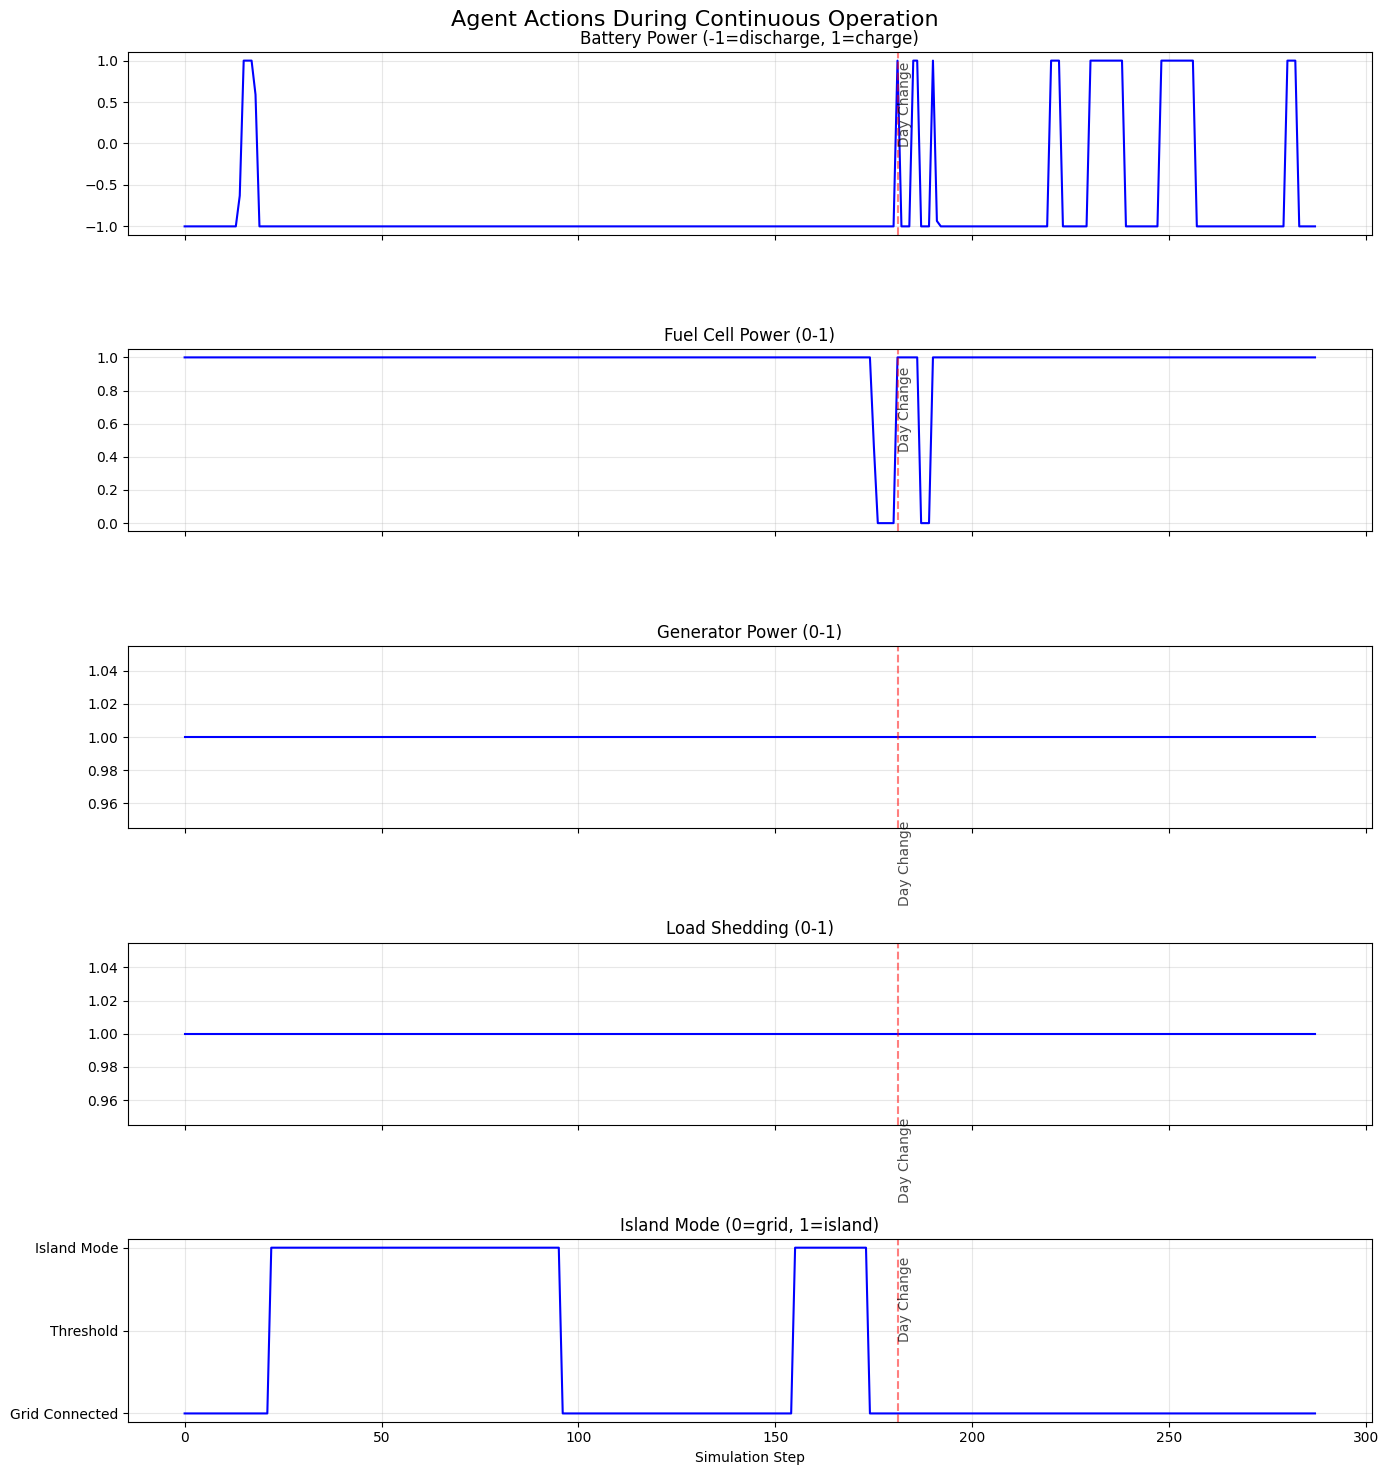

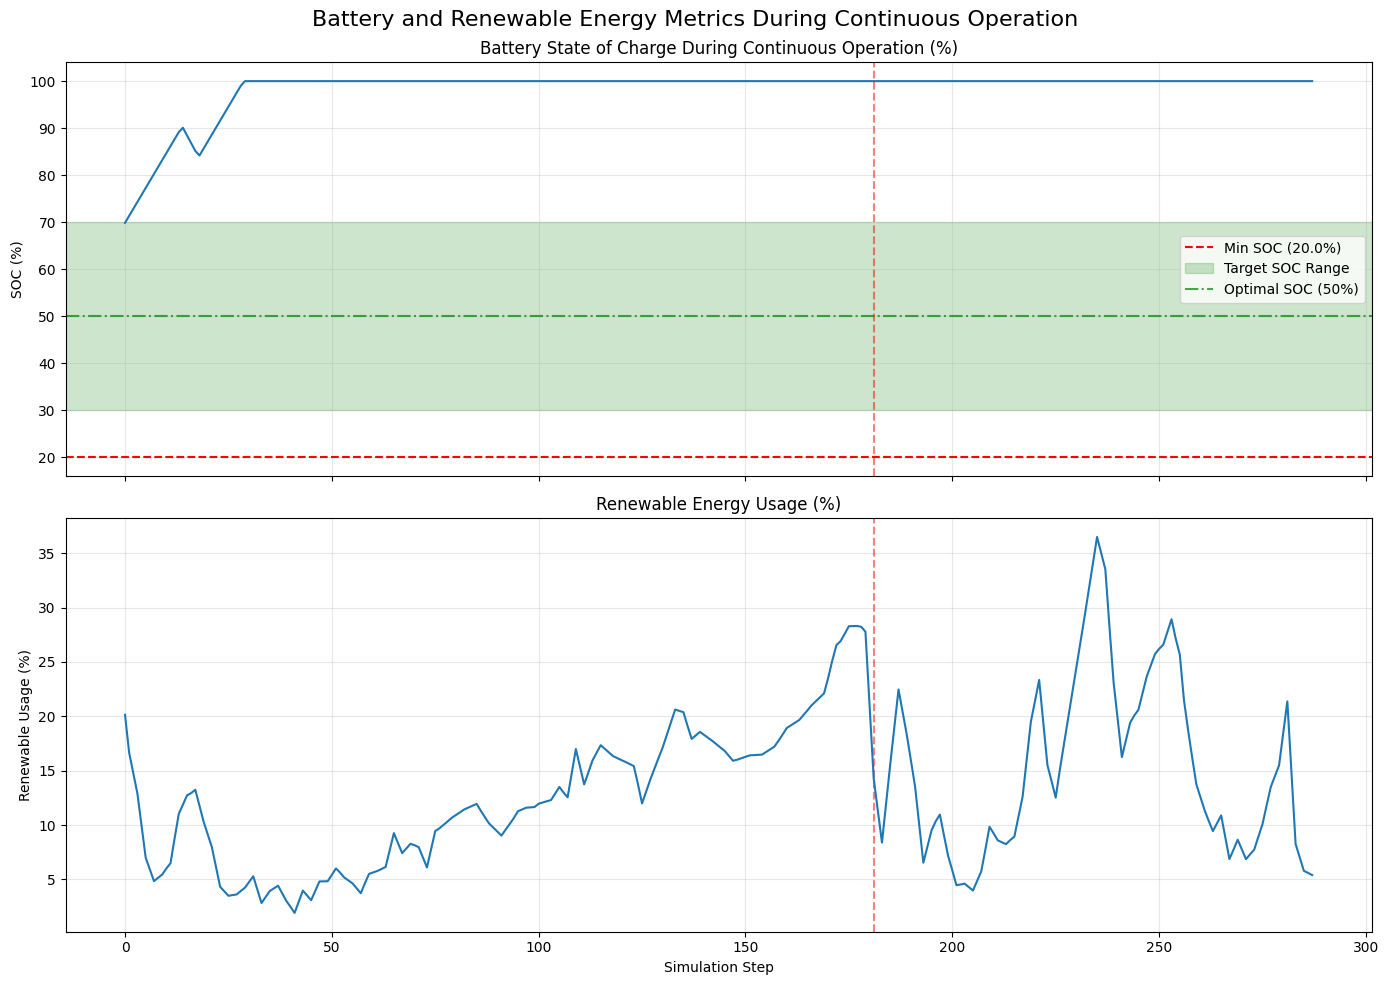

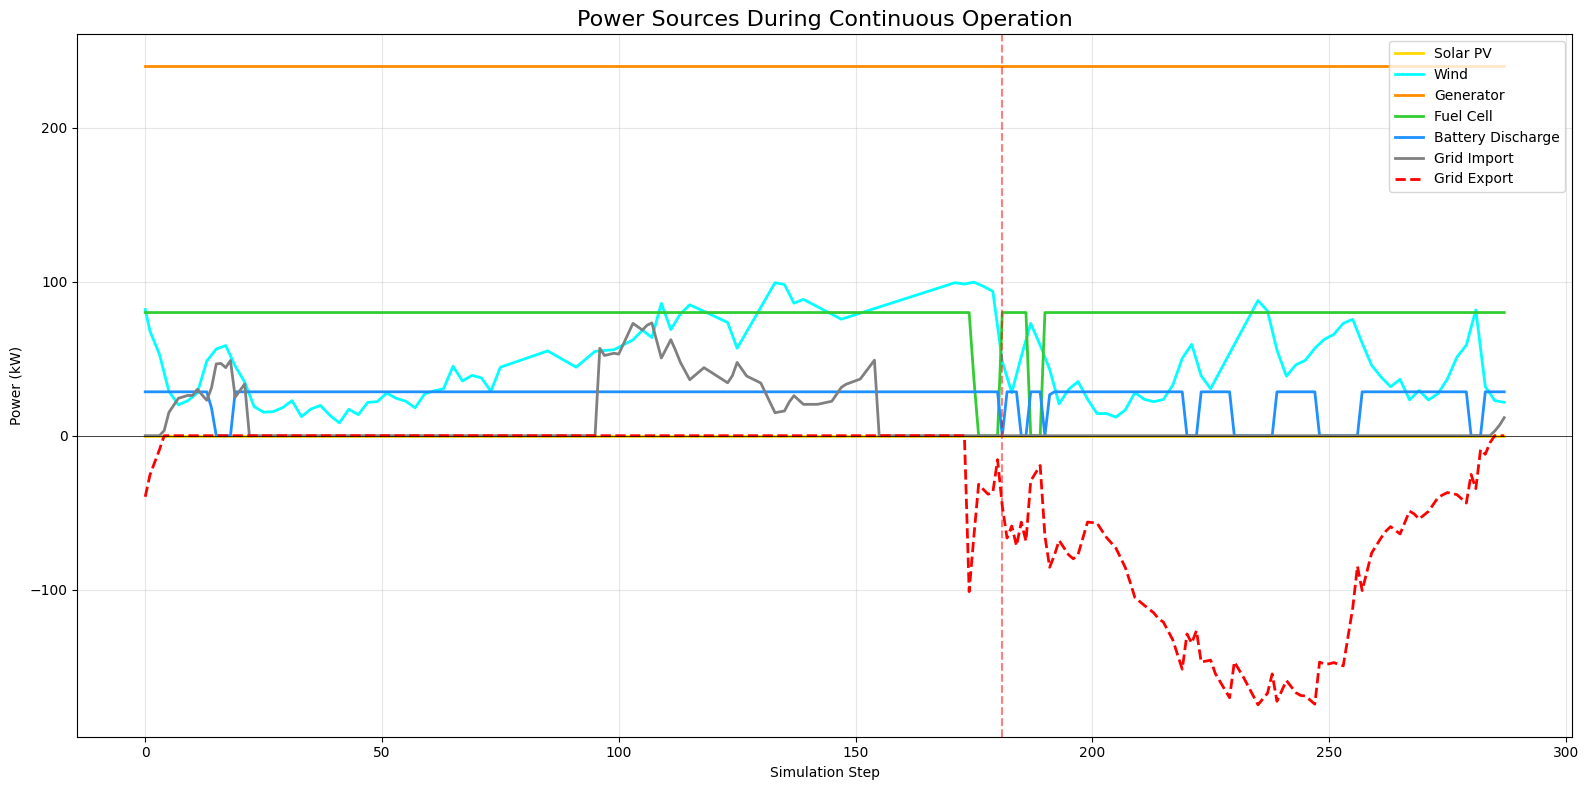

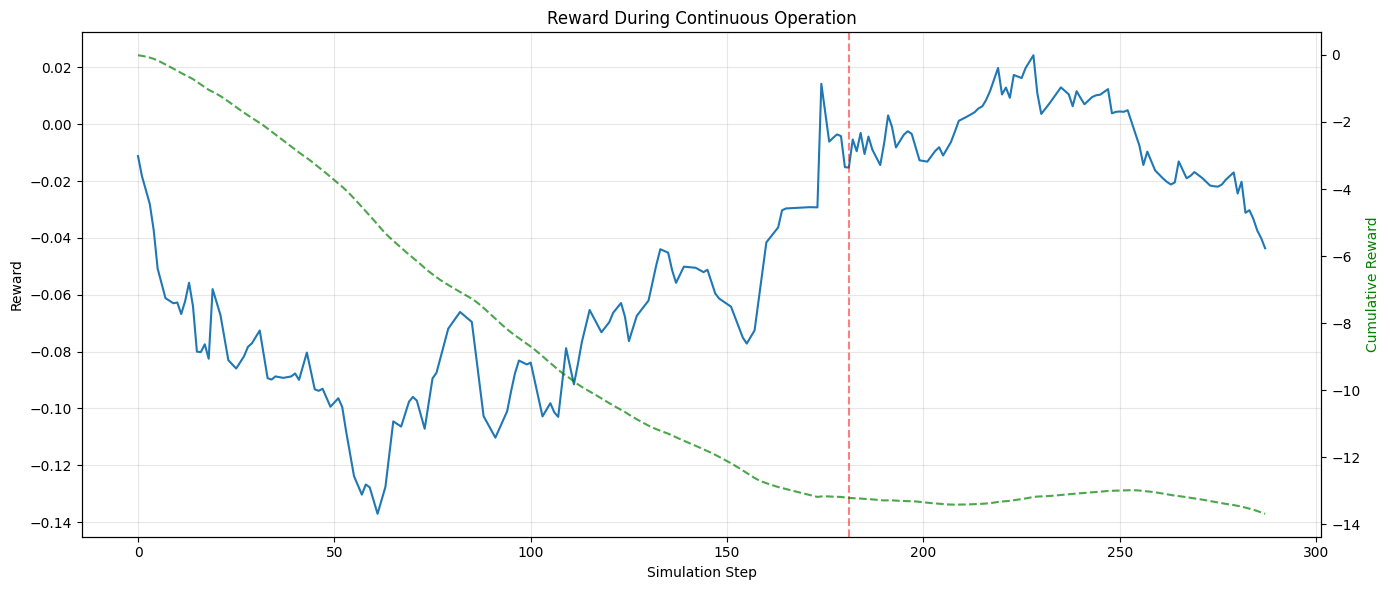

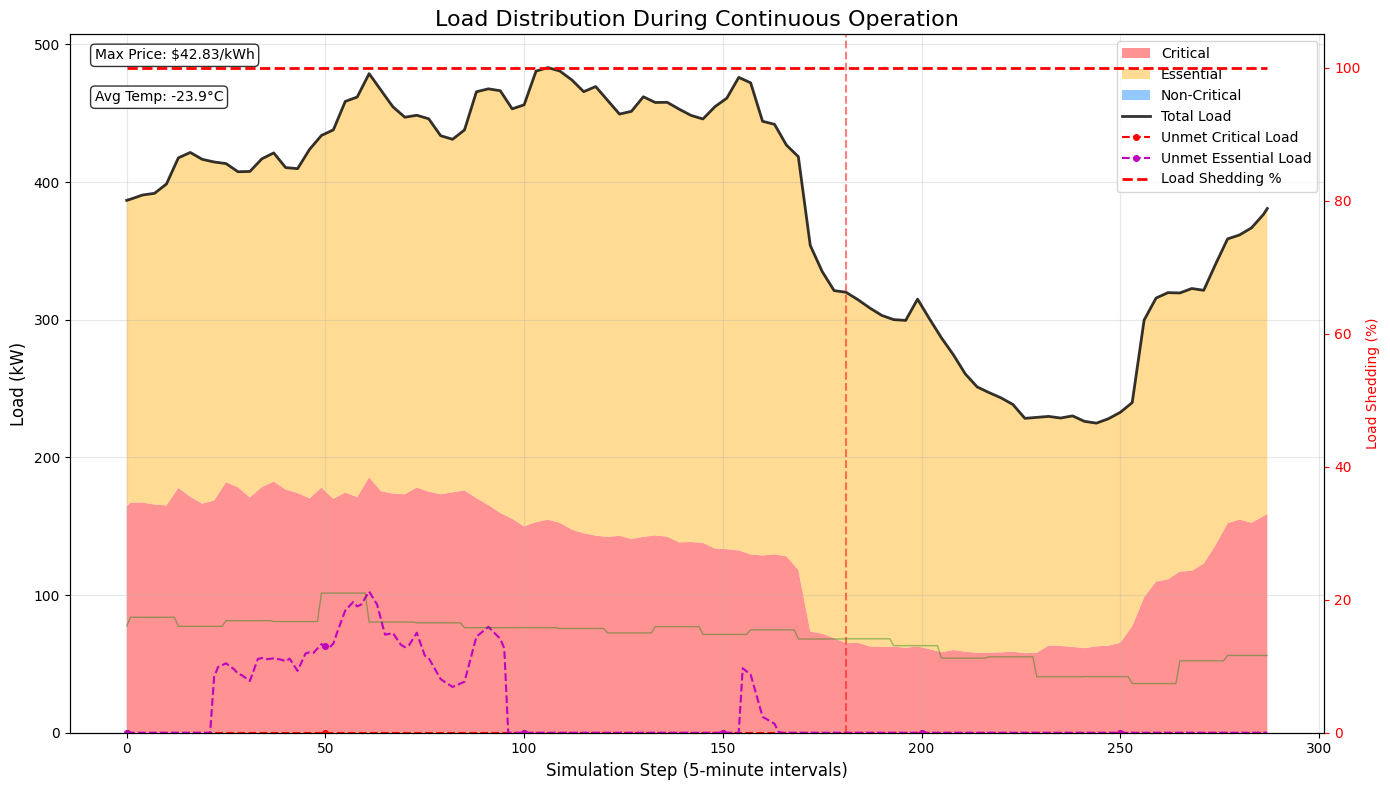

Continuous Simulation Summary:
- Total steps: 288
- Simulation time: 24.0 hours (2 days)
- Average renewable usage: 13.4%
- Average grid dependence: 2.3%
- Time in island mode: 32.3%


In [82]:
results = visualize_continuous_inference(model, env, num_steps=288*1)